<a href="https://colab.research.google.com/github/LiYuan199701/TimeSeries/blob/Bayesian-single-perceptron-TS/Grid_Search_Bernstein_basis_BNAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load packages

In [ ]:
# ===============================
# Bayesian single-perceptron NAR(d)
# with recency-decaying prior means
# ===============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from joblib import Parallel, delayed
import multiprocessing

%matplotlib inline
# Set inline backend and resolution
%config InlineBackend.figure_format = 'retina'  # For Retina displays
plt.rcParams['figure.dpi'] = 150  # Set dpi to 200 for high resolution

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate the Bernstein Polynomial Approximation

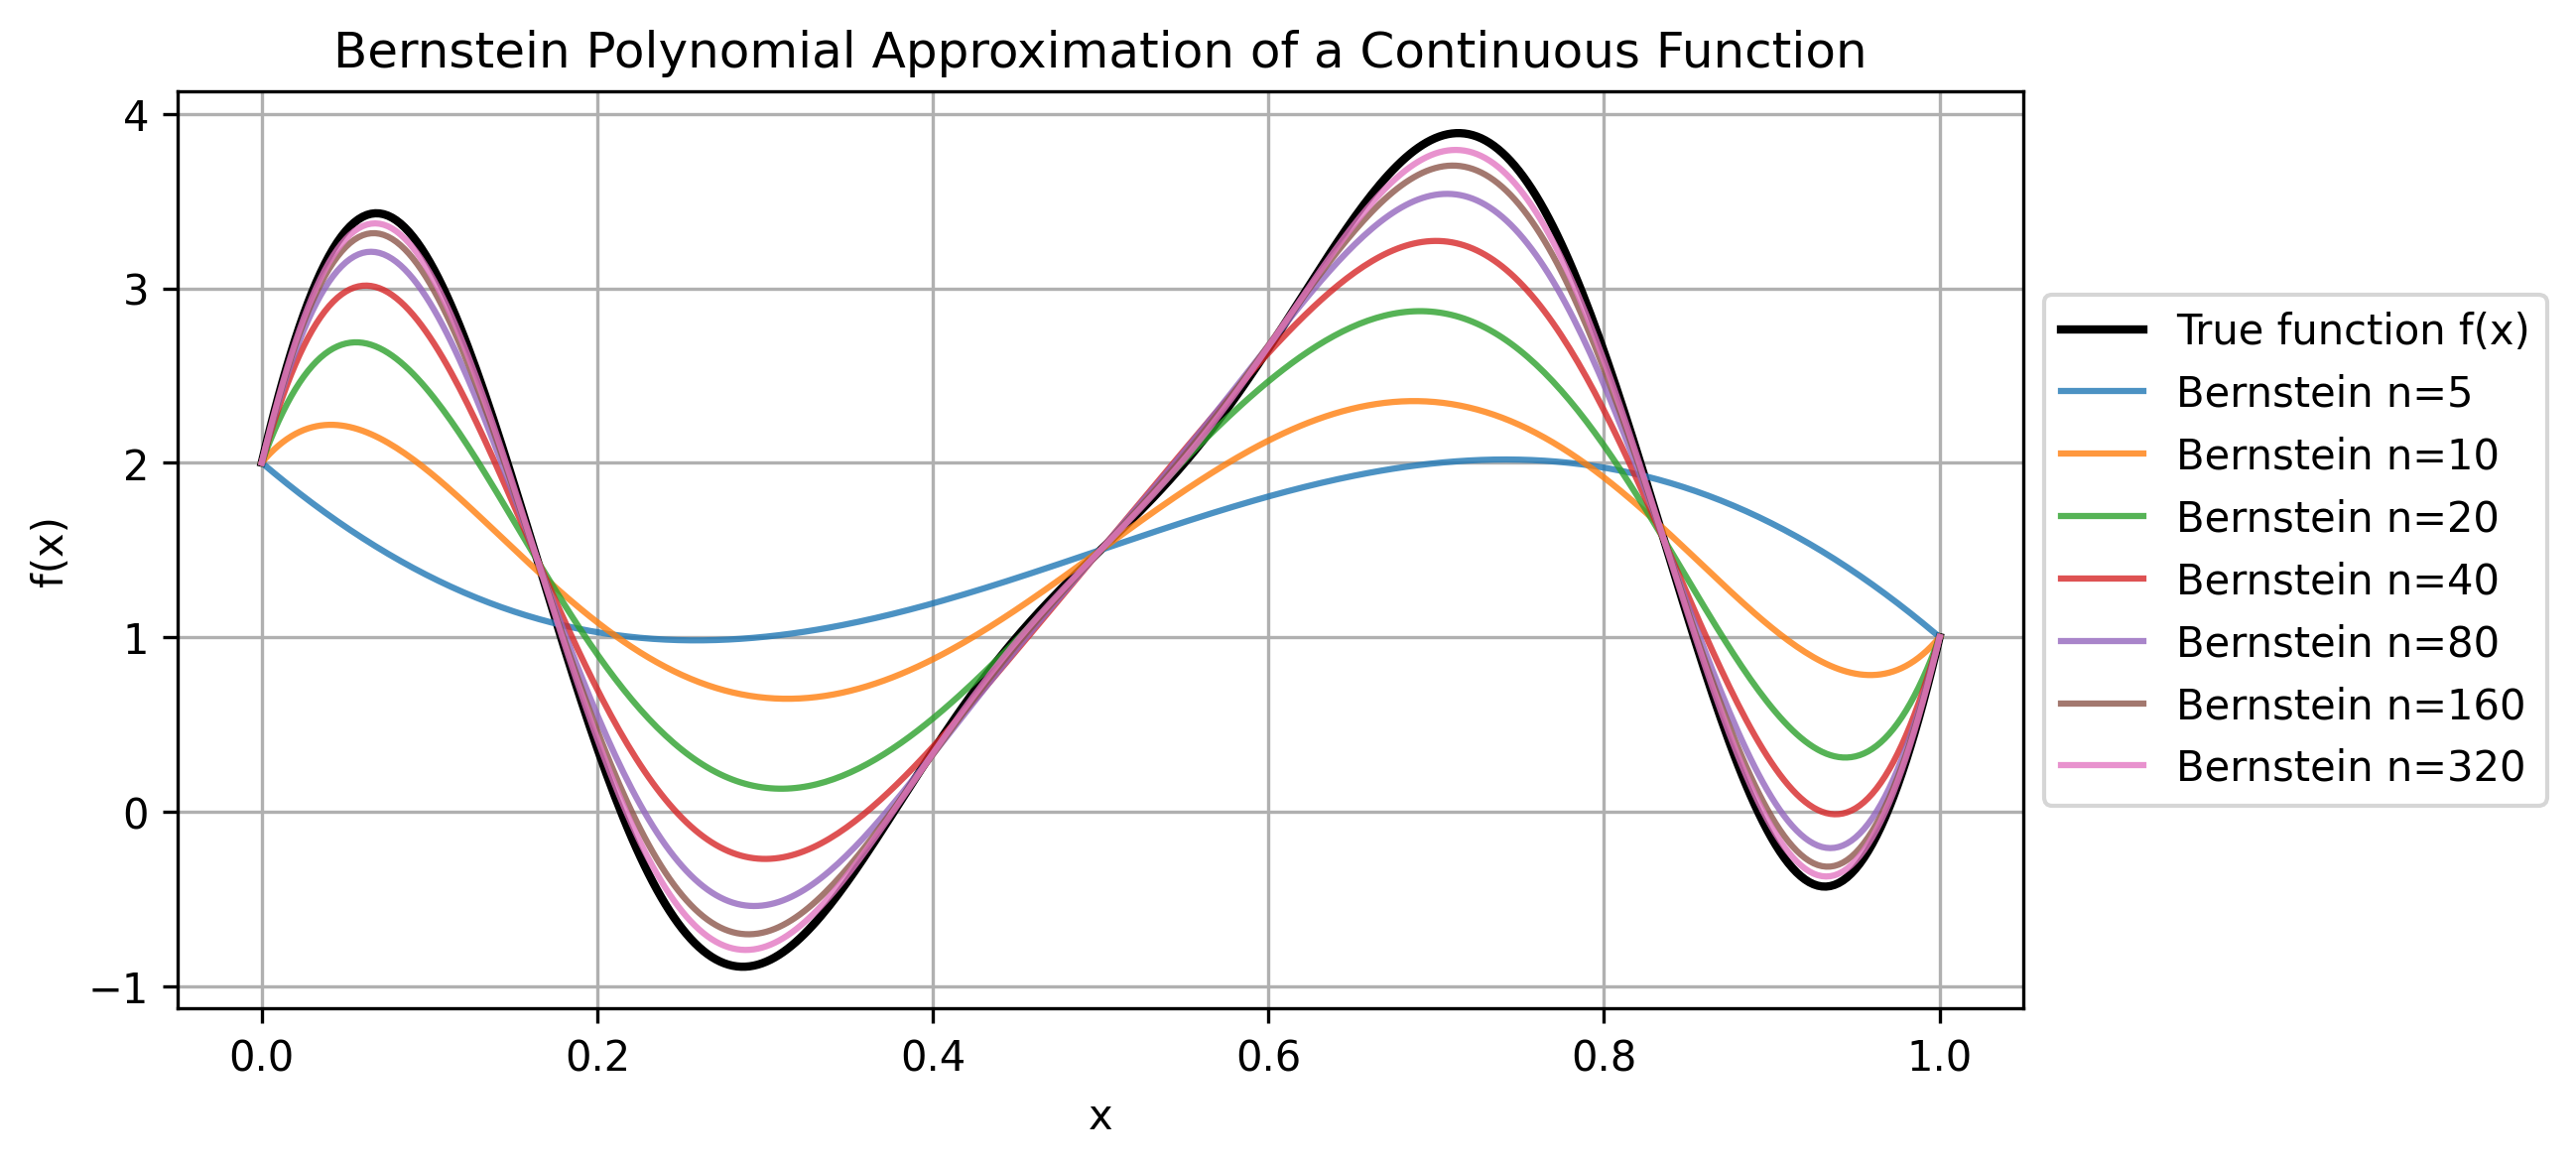

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
import math

# ============================================================
# Bernstein basis function (provided by you)
# ============================================================
def bernstein_basis_1d(z, degree):
    """
    z: shape (N,)
    degree: Bernstein degree n

    Returns:
        B: shape (N, degree+1)
        Each column k is B_{k,n}(z)
    """
    z = np.asarray(z).reshape(-1)
    N = len(z)
    B = np.zeros((N, degree+1))

    for k in range(degree+1):
        B[:, k] = comb(degree, k) * (z**k) * ((1 - z)**(degree - k))

    return B


# ============================================================
# 1. Simulated continuous function on [0,1]
# ============================================================
def f(x):
    return 3*x + 3*np.sin(4*np.pi*x) + 2*np.cos(5*np.pi*x)

# grid on [0,1]
x = np.linspace(0, 1, 400)
fx = f(x)

# ============================================================
# 2. Bernstein approximation for degree n
# ============================================================
def bernstein_approx(f, x, degree):
    """
    Compute Bernstein approximation B_n(f)(x)
    """
    n = degree

    # f(k/n) for k=0,...,n
    sample_points = np.linspace(0, 1, n+1)
    f_samples = f(sample_points)    # shape (n+1,)

    # construct Bernstein basis for each x
    B = bernstein_basis_1d(x, n)    # shape (len(x), n+1)

    # B_n(f)(x) = sum_k f(k/n) * B_{k,n}(x)
    return B @ f_samples


# ============================================================
# 3. Plot true function and approximations
# ============================================================
degrees = [5, 10, 20, 40, 80, 160, 320]

plt.figure(figsize=(8, 4))
plt.plot(x, fx, 'k-', linewidth=2, label="True function f(x)")

for n in degrees:
    approx = bernstein_approx(f, x, n)
    plt.plot(x, approx, label=f"Bernstein n={n}", alpha=0.8)

plt.title("Bernstein Polynomial Approximation of a Continuous Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()

# Define the simulation models

In [ ]:
# ============================================
#   MODEL 1
# ============================================
def simulate_model1(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        if X[t-1] <= 0:
            X[t] = 0.1 * X[t-1] + eps
        else:
            X[t] = 0.8 * X[t-1] + eps
    return X

# ============================================
#   MODEL 2
# ============================================
def simulate_model2(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[:3] = np.random.randn(3)

    for t in range(3, T):
        eps = np.random.randn() * sigma_eps
        if X[t-1] <= 0:
            X[t] = 0.5*X[t-1] + 0.2*X[t-2] + 0.1*X[t-3] + eps
        else:
            X[t] = 0.8*X[t-1] + eps
    return X

# ============================================
#   MODEL 3
# ============================================
def simulate_model3(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn()
        if X[t-1] <= 0:
            X[t] = 0.1 * X[t-1] + 0.5*np.exp(-X[t-1]**2) * eps
        else:
            X[t] = 0.8 * X[t-1] + 0.5*np.exp(-X[t-1]**2) * eps
    return X

# ============================================
#   MODEL 4
# ============================================
def simulate_model4(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        X[t] = 0.2 + np.log(0.5 + np.abs(X[t-1])) + eps
    return X

# ============================================
#   MODEL 5
# ============================================
def simulate_model5(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn() + 1.0

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        X[t] = 2 * np.log(X[t-1]**2 + 1e-6) + eps
    return X

# ============================================
#   MODEL 6
# ============================================
def simulate_model6(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        X[t] = np.log(10 + 5 * np.exp(0.9 * X[t-1])) + eps
    return X

# ============================================
#   MODEL 7
# ============================================
def simulate_model7(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[:3] = np.random.randn(3)

    for t in range(3, T):
        eps = np.random.randn() * sigma_eps
        term = (4*np.exp(0.9*X[t-2]) +
                5*np.exp(0.9*X[t-1]) +
                6*np.exp(0.9*X[t-3]))
        X[t] = np.log(term) + eps
    return X

# =====================================================
# Unified wrapper
# =====================================================
def simulate(model_id, T=2000, sigma_eps=1.0):
    if model_id == 1: return simulate_model1(T, sigma_eps)
    if model_id == 2: return simulate_model2(T, sigma_eps)
    if model_id == 3: return simulate_model3(T, sigma_eps)
    if model_id == 4: return simulate_model4(T, sigma_eps)
    if model_id == 5: return simulate_model5(T, sigma_eps)
    if model_id == 6: return simulate_model6(T, sigma_eps)
    if model_id == 7: return simulate_model7(T, sigma_eps)
    raise ValueError("Model ID must be 1–7")

# Generate simulation data

x_min: -3.22108962580138
x_max: 3.7164585876811453
x_mean: 0.4132982858412381
x_std: 1.1321191491951828


Text(0.5, 1.0, 'Model 4 Time Series')

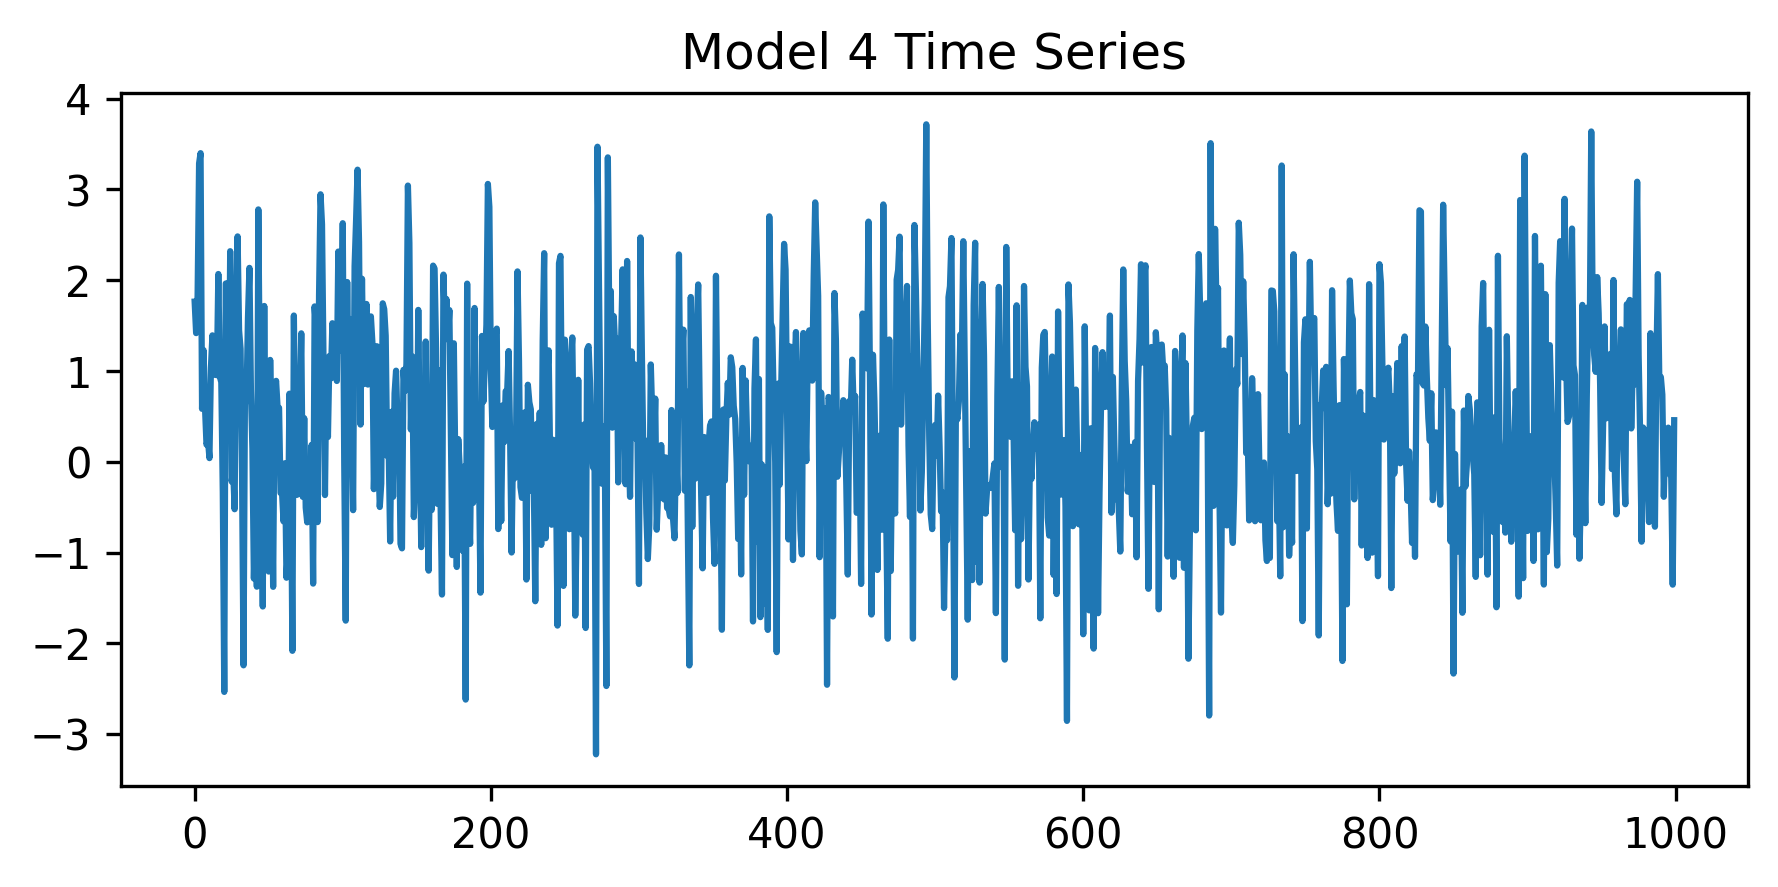

In [58]:
# Set a random seed
np.random.seed(0)
# Set the number of samples
T = 1000
id = 4
x = simulate(model_id=id, T = T)
# create the summary statistics of x time series including min and max
x_min = np.min(x)
x_max = np.max(x)
x_mean = np.mean(x)
x_std = np.std(x)
# print the summary statistics
print("x_min:", x_min)
print("x_max:", x_max)
print("x_mean:", x_mean)
print("x_std:", x_std)

# plot this time series
plt.figure(figsize=(7,3))
plt.plot(x)
# change title name by model id
plt.title(f"Model {id} Time Series")

# Define functions to form lag and build nonlinear basis

In [ ]:
import numpy as np
import torch

# ----------------------------------------------------------
# 1. Scaling function
# ----------------------------------------------------------
def scale_to_unit_interval(X, do_scale=True):
    """
    Scale time series X to [-1, 1] ONLY IF:
        (1) do_scale=True, AND
        (2) X is not already in [-1, 1].

    Returns:
        X_scaled, scale_factor c
    """
    X = np.asarray(X).reshape(-1)

    # If user disables scaling
    if not do_scale:
        return X, 1.0

    X_min = np.min(X)
    X_max = np.max(X)

    # If the entire series is already within [-1, 1], don't scale
    if X_min >= -1.0 and X_max <= 1.0:
        return X, 1.0

    # Otherwise compute scale c
    c = max(abs(X_min), abs(X_max))
    if c < 1e-12:
        c = 1.0   # avoid divide-by-zero for constant series

    return X / c, c



# ----------------------------------------------------------
# 2. Build lag matrix
# ----------------------------------------------------------
def build_lag_matrix(x, d):
    """
    x: 1-D array (N,)
    d: number of lags

    Returns:
        X_lag: shape (N-d, d)
        y:     shape (N-d,)
    """
    x = np.asarray(x).reshape(-1)
    N = len(x)

    X_lag = np.zeros((N - d, d))
    for k in range(1, d + 1):
        X_lag[:, k - 1] = x[d - k : N - k]

    y = x[d:]
    return X_lag, y

# ----------------------------------------------------------
# A. Bernstein basis for a single normalized variable z∈[0,1]
# ----------------------------------------------------------
import numpy as np
from math import comb

def bernstein_basis_1d(z, degree):
    """
    z: shape (N,)
    degree: Bernstein degree n

    Returns:
        B: shape (N, degree+1)
        Each column k is B_{k,n}(z)
    """
    z = np.asarray(z).reshape(-1)
    N = len(z)
    B = np.zeros((N, degree+1))

    for k in range(degree+1):
        B[:, k] = comb(degree, k) * (z**k) * ((1 - z)**(degree - k))

    return B

# ----------------------------------------------------------
# B. Build full Bernstein basis for AR(d) lag matrix
# ----------------------------------------------------------
def build_bernstein_full_basis(X_lag, degree=5):
    """
    X_lag: shape (N, d) lag matrix
    For each lag column, apply Bernstein basis separately.
    """
    X_lag = np.asarray(X_lag)
    N, d = X_lag.shape
    basis_list = []

    # normalize each lag independently into [0,1]
    # Bernstein requires z ∈ [0,1]
    X_min = X_lag.min(axis=0)
    X_max = X_lag.max(axis=0)
    X_range = X_max - X_min + 1e-8
    Z = (X_lag - X_min) / X_range

    for j in range(d):
        Bj = bernstein_basis_1d(Z[:, j], degree)
        basis_list.append(Bj)

    return np.concatenate(basis_list, axis=1)

# Scale Data

Text(0.5, 1.0, 'Scaled Model 4 Time Series')

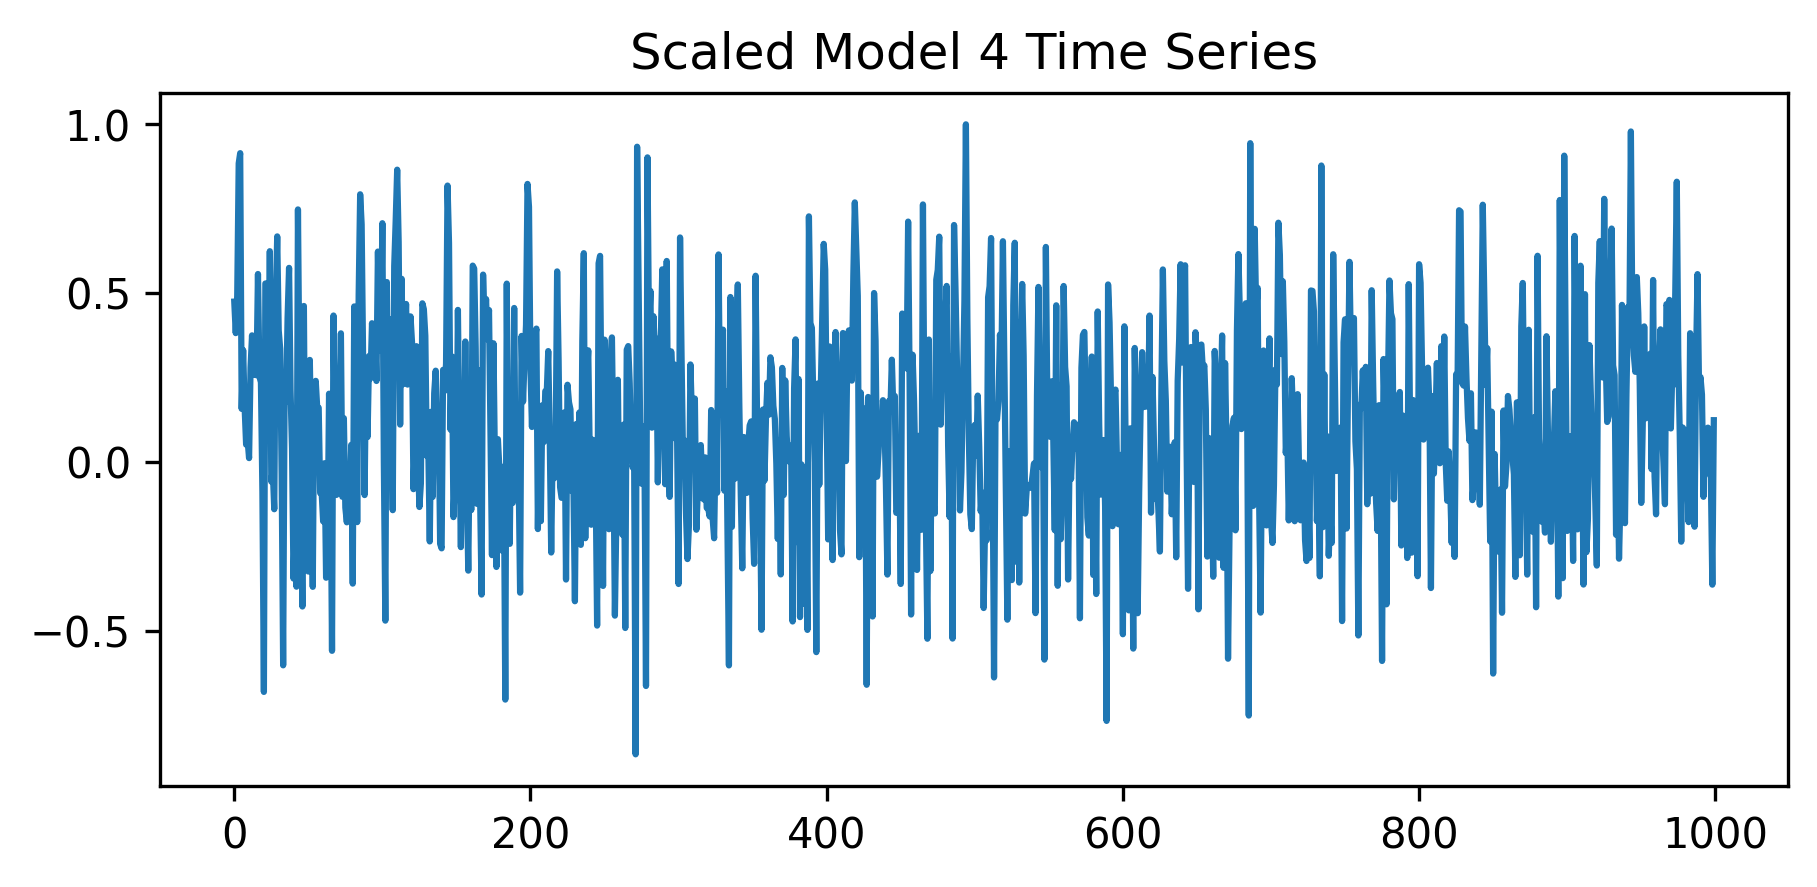

In [59]:
x_scaled, c = scale_to_unit_interval(x, True)
# plot this time series
plt.figure(figsize=(7,3))
plt.plot(x_scaled)
# change title name by model id
plt.title(f"Scaled Model {id} Time Series")

# Define BNAR_FullCov Model

In [ ]:
# ============================================
# Module 2: model_block.py
# BNAR-FullCov with Independent Gaussian Prior
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class BNAR_FullCov(nn.Module):

    def __init__(self, d, activation="tanh", prior_std=1.0, sigma_floor = 0.9):
        """
        d: number of basis-expanded input features
        activation: "tanh", "identity", "relu", "elu", "softplus"
        prior_std: std of independent Gaussian prior p(w) = N(0, prior_std^2 I)
        """
        super().__init__()
        self.d = d
        self.prior_std = prior_std
        self.activation_name = activation
        self.activation = self.get_activation(activation)
        self.sigma_floor = sigma_floor

        # variational mean
        self.m_w = nn.Parameter(torch.randn(d) * 0.1)

        # diagonal log std for Lq diagonal
        self.log_diag_Lq = nn.Parameter(torch.full((d,), math.log(0.1)))

        # strictly lower triangular unconstrained parameters
        tril_idx = torch.tril_indices(d, d, offset=-1)
        self.Lq_offdiag = nn.Parameter(torch.zeros(tril_idx.shape[1]))

        # bias term
        self.b = nn.Parameter(torch.tensor(0.0))

        # observation noise (Gaussian)
        self.log_sigma_eps = nn.Parameter(torch.tensor(math.log(0.1)))

    # ------------------------------------------------------------
    def get_activation(self, name):
        if name == "tanh":
            return torch.tanh
        elif name == "identity":
            return lambda x: x
        elif name == "relu":
            return F.relu
        elif name == "elu":
            return F.elu
        elif name == "softplus":
            return F.softplus
        else:
            raise ValueError(f"Unknown activation: {name}")

    # ------------------------------------------------------------
    def get_Lq(self, device):
        """Build lower triangular matrix L_q."""
        L_q = torch.zeros(self.d, self.d, device=device)
        tril_idx = torch.tril_indices(self.d, self.d, offset=-1)

        # fill strictly lower elements
        L_q[tril_idx[0], tril_idx[1]] = self.Lq_offdiag

        # add positive diagonal
        L_q = L_q + torch.diag(torch.exp(self.log_diag_Lq))
        return L_q

    # ------------------------------------------------------------
    def kl_gaussian_full(self, mu_q, L_q):
        """
        KL( q(w) || p(w) )
        Prior: p(w) = N(0, prior_std^2 I)
        q(w) = N(mu_q, L_q L_q^T)
        """
        d = mu_q.shape[0]
        Sigma_q = L_q @ L_q.T

        # prior precision: 1 / prior_std^2
        prior_var = self.prior_std ** 2
        Sigma_p_inv = torch.eye(d, device=mu_q.device) / prior_var

        trace_term = torch.trace(Sigma_p_inv @ Sigma_q)
        quad_term = (mu_q @ Sigma_p_inv @ mu_q)

        # log determinants
        log_det_q = 2 * torch.sum(torch.log(torch.diag(L_q)))
        log_det_p = d * math.log(prior_var)

        kl = 0.5 * (trace_term + quad_term - d + log_det_p - log_det_q)
        return kl

    # ------------------------------------------------------------
    def forward(self, X, sample=True, kl_weight=1.0):
        """
        X: (n_samples, d) tensor
        """
        device = X.device
        L_q = self.get_Lq(device)

        if sample and self.training:
            eps = torch.randn(self.d, device=device)
            w = self.m_w + L_q @ eps
        else:
            w = self.m_w

        lin = (X @ w).unsqueeze(1) + self.b
        yhat = self.activation(lin)

        sigma_eps = F.softplus(self.log_sigma_eps) + self.sigma_floor
        kl = self.kl_gaussian_full(self.m_w, L_q)

        return yhat, sigma_eps, kl_weight * kl

    # ------------------------------------------------------------
    def negative_elbo(self, X, y, kl_weight=1.0):
        yhat, sigma_eps, kl_term = self.forward(X, sample=True, kl_weight=kl_weight)

        n = X.shape[0]
        log_likelihood = (
            -0.5 * n * torch.log(2 * torch.tensor(math.pi) * sigma_eps**2)
            - 0.5 * torch.sum((y - yhat)**2) / (sigma_eps**2)
        )

        return -log_likelihood + kl_term, yhat

# Define Train_Evaluate function

In [ ]:
import numpy as np
import pandas as pd
import torch
from statsmodels.stats.diagnostic import acorr_ljungbox

def train_and_evaluate_bnar(
    x_scaled,
    build_lag_matrix,
    build_bernstein_full_basis,
    model_class,
    d,
    degree,
    device,
    n_epochs=3000,
    lr=1e-3,
    kl_weight=0.1,
    ljung_lag=20,
    activation="tanh",
    prior_std=1.0,
    sigma_floor=1e-6,
):
    """
    Train one Bernstein-BNAR model and return metrics.
    """

    # -------------------------
    # Build lagged design
    # -------------------------
    X_lag, y = build_lag_matrix(x_scaled, d)

    X_basis = build_bernstein_full_basis(X_lag, degree=degree)

    N = len(y)
    n_train = int(0.7 * N)
    n_val   = int(0.15 * N)

    idx_tr = slice(0, n_train)
    idx_va = slice(n_train, n_train + n_val)
    idx_te = slice(n_train + n_val, N)

    Xtr, ytr = X_basis[idx_tr], y[idx_tr]
    Xva, yva = X_basis[idx_va], y[idx_va]
    Xte, yte = X_basis[idx_te], y[idx_te]

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).unsqueeze(1)
    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
    yva_t = torch.tensor(yva, dtype=torch.float32, device=device).unsqueeze(1)
    Xte_t = torch.tensor(Xte, dtype=torch.float32, device=device)
    yte_t = torch.tensor(yte, dtype=torch.float32, device=device).unsqueeze(1)

    # -------------------------
    # Model
    # -------------------------
    model = model_class(
    d=Xtr.shape[1],
    activation=activation,
    prior_std=prior_std,
    sigma_floor=sigma_floor).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        nelbo, _ = model.negative_elbo(Xtr_t, ytr_t, kl_weight=kl_weight)
        nelbo.backward()
        optimizer.step()

    # -------------------------
    # Evaluation
    # -------------------------
    model.eval()
    with torch.no_grad():
        ytr_hat, sigma_tr, _ = model.forward(Xtr_t, sample=False)
        yva_hat, sigma_va, _ = model.forward(Xva_t, sample=False)
        yte_hat, sigma_te, _ = model.forward(Xte_t, sample=False)

    # Convert to numpy
    ytr_hat = ytr_hat.cpu().numpy().flatten()
    yva_hat = yva_hat.cpu().numpy().flatten()
    yte_hat = yte_hat.cpu().numpy().flatten()

    # RMSE
    rmse_tr = np.sqrt(np.mean((ytr - ytr_hat) ** 2))
    rmse_va = np.sqrt(np.mean((yva - yva_hat) ** 2))
    rmse_te = np.sqrt(np.mean((yte - yte_hat) ** 2))

    # Residuals
    res_tr = ytr - ytr_hat
    res_va = yva - yva_hat
    res_te = yte - yte_hat

    # Ljung–Box
    lb_tr = acorr_ljungbox(res_tr, lags=[ljung_lag], return_df=True)
    lb_va = acorr_ljungbox(res_va, lags=[ljung_lag], return_df=True)
    lb_te = acorr_ljungbox(res_te, lags=[ljung_lag], return_df=True)

    return {
        "d": d,
        "degree": degree,
        "rmse_train": rmse_tr,
        "rmse_val": rmse_va,
        "rmse_test": rmse_te,
        "lb_p_train": lb_tr["lb_pvalue"].iloc[0],
        "lb_p_val": lb_va["lb_pvalue"].iloc[0],
        "lb_p_test": lb_te["lb_pvalue"].iloc[0],
    }

# Define the grid search pattern

In [ ]:
# Hyperparameter grids
lag_grid        = [2, 3, 4, 5, 6, 7]
degree_grid     = [8, 9, 10, 11, 12, 13, 14, 15]
activation_grid = ["tanh"]
prior_std_grid  = [1.0]

# Cartesian product
grid = [
    (d, deg, act, ps)
    for d in lag_grid
    for deg in degree_grid
    for act in activation_grid
    for ps in prior_std_grid
]

print(f"Total models to train: {len(grid)}")

Total models to train: 48


# Define Parallization Function

In [ ]:
def run_one_config(cfg):
    d, degree, activation, prior_std = cfg

    try:
        metrics = train_and_evaluate_bnar(
            x_scaled=x_scaled,
            build_lag_matrix=build_lag_matrix,
            build_bernstein_full_basis=build_bernstein_full_basis,
            model_class=BNAR_FullCov,
            d=d,
            degree=degree,
            device=device,
            activation=activation,
            prior_std=prior_std,
            sigma_floor=1e-6,
            n_epochs=3000,
            kl_weight=0.1,
        )
        return metrics

    except Exception as e:
        print(f"FAILED: d={d}, deg={degree}, act={activation}, ps={prior_std}")
        print(e)
        return None

# Run the Parallel computing

In [ ]:
n_jobs = max(1, multiprocessing.cpu_count() - 1)

results = Parallel(
    n_jobs=n_jobs,
    verbose=10
)(
    delayed(run_one_config)(cfg) for cfg in grid
)

# Drop failed runs
results = [r for r in results if r is not None]

df_results = pd.DataFrame(results)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    7.1s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   25.3s
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:   44.0s
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:  1.8min
[Parallel(n_jobs=1)]: Done  24 tasks      | elapsed:  2.5min
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:  3.3min
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  4.4min
[Parallel(n_jobs=1)]: Done  48 out of  48 | elapsed:  5.4min finished


# Visualize the RMSE vs Ljung–Box Trade-off

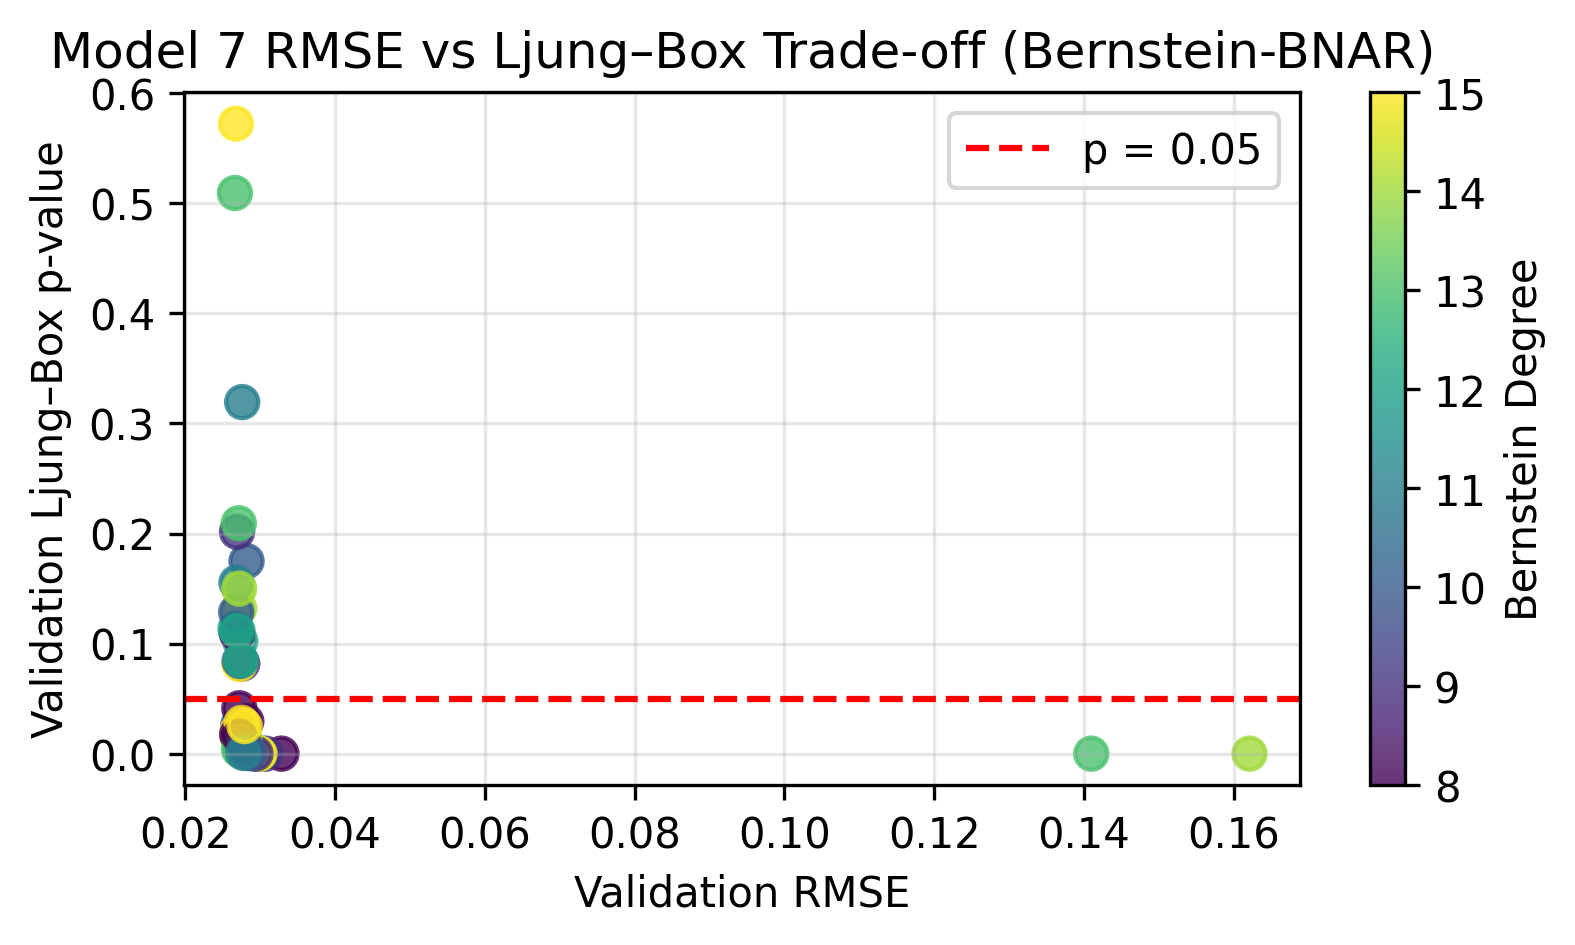

In [ ]:
plt.figure(figsize=(6, 3))

scatter = plt.scatter(
    df_results["rmse_val"],
    df_results["lb_p_val"],
    c=df_results["degree"],
    cmap="viridis",
    s=60,
    alpha=0.8,
)

plt.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
plt.xlabel("Validation RMSE")
plt.ylabel("Validation Ljung–Box p-value")
plt.title(f"Model {id} RMSE vs Ljung–Box Trade-off (Bernstein-BNAR)")
plt.colorbar(scatter, label="Bernstein Degree")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Define Pareto Front

In [ ]:
def pareto_front(df, rmse_col, pval_col):
    is_pareto = np.ones(len(df), dtype=bool)

    for i, row in df.iterrows():
        dominates = (
            (df[rmse_col] <= row[rmse_col]) &
            (df[pval_col] >= row[pval_col]) &
            (
                (df[rmse_col] < row[rmse_col]) |
                (df[pval_col] > row[pval_col])
            )
        )
        if dominates.any():
            is_pareto[i] = False

    return df[is_pareto]

df_pareto = pareto_front(df_results, "rmse_val", "lb_p_val")

# Visualize Pareto Front: Accuracy vs Residual Whiteness

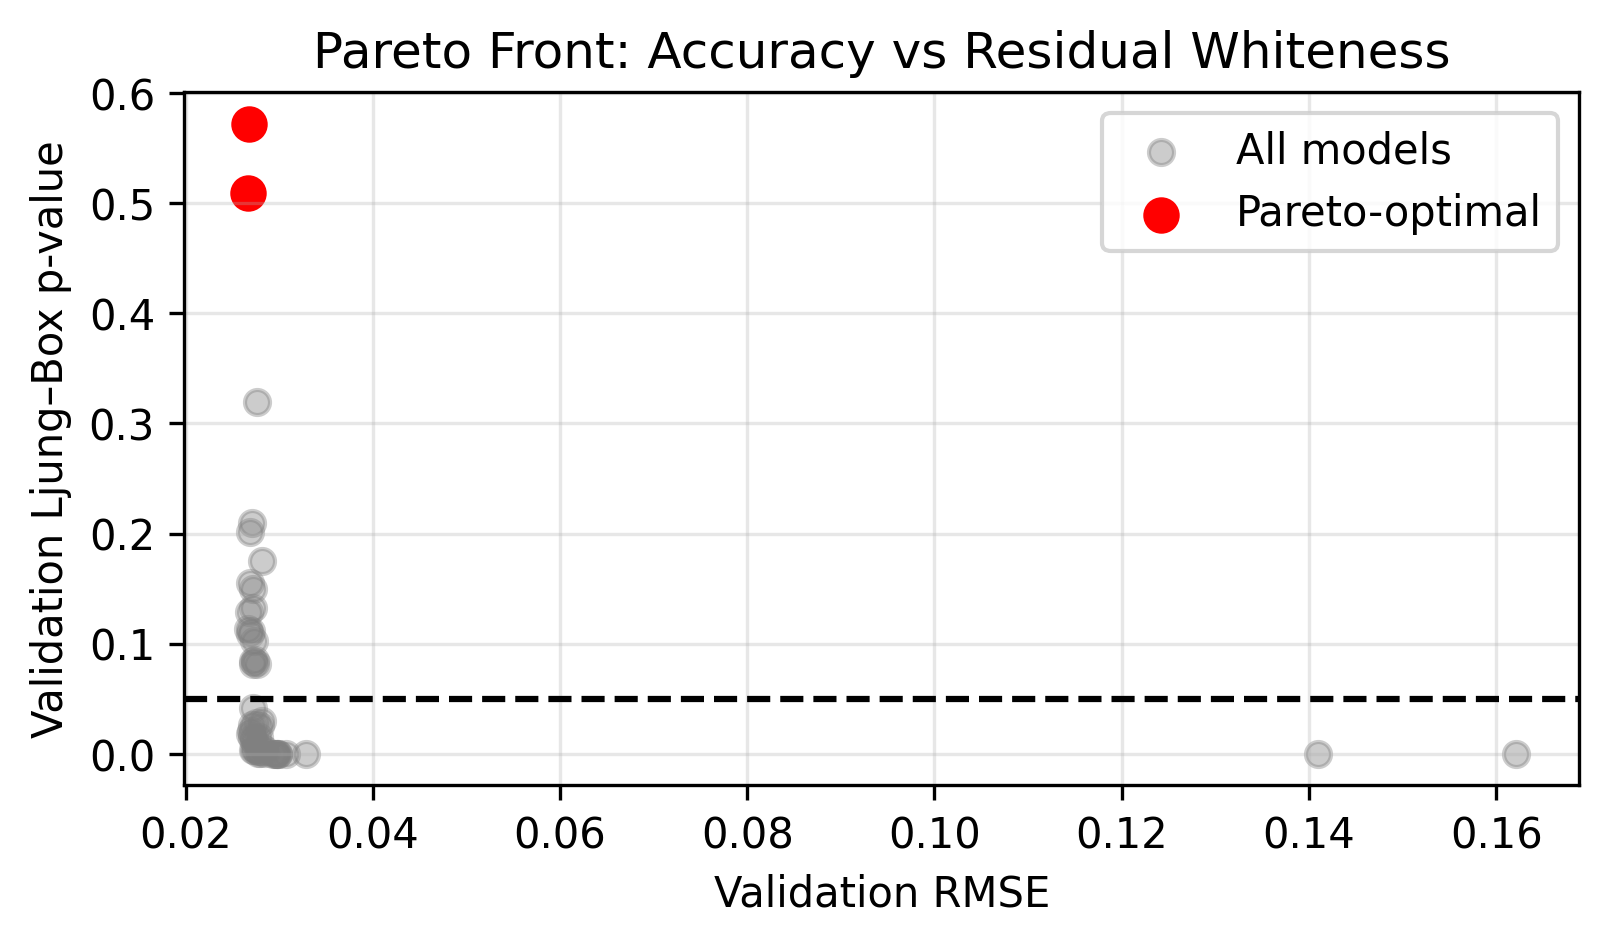

In [ ]:
plt.figure(figsize=(6, 3))

plt.scatter(
    df_results["rmse_val"],
    df_results["lb_p_val"],
    color="gray",
    alpha=0.4,
    label="All models"
)

plt.scatter(
    df_pareto["rmse_val"],
    df_pareto["lb_p_val"],
    color="red",
    s=60,
    label="Pareto-optimal"
)

plt.axhline(0.05, color="black", linestyle="--")
plt.xlabel("Validation RMSE")
plt.ylabel("Validation Ljung–Box p-value")
plt.title("Pareto Front: Accuracy vs Residual Whiteness")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find out the Best Model

In [ ]:
# Acceptable models
acceptable = df_results[df_results["lb_p_val"] >= 0.05]

# Best among acceptable
hard_best_model = acceptable.sort_values("rmse_val").iloc[0]

hard_best_model

,13
d,3.000000e+00
degree,1.300000e+01
rmse_train,3.129911e-02
rmse_val,2.663440e-02
rmse_test,3.375391e-02
lb_p_train,2.706256e-42
lb_p_val,5.093228e-01
lb_p_test,2.129615e-26


# Soft Best Model

In [ ]:
# Soft compromise
soft_best_model = df_results.sort_values(
    by=["rmse_val", "lb_p_val"],
    ascending=[True, False]
).iloc[0]
soft_best_model

,13
d,3.000000e+00
degree,1.300000e+01
rmse_train,3.129911e-02
rmse_val,2.663440e-02
rmse_test,3.375391e-02
lb_p_train,2.706256e-42
lb_p_val,5.093228e-01
lb_p_test,2.129615e-26


# Evaluate


Training final model...
Epoch    0 | NELBO=23996.158 | Val RMSE=0.8363
Epoch  500 | NELBO=-306.480 | Val RMSE=0.1232
Epoch 1000 | NELBO=-771.712 | Val RMSE=0.0487
Epoch 1500 | NELBO=-859.531 | Val RMSE=0.0335
Epoch 2000 | NELBO=-906.144 | Val RMSE=0.0296
Epoch 2500 | NELBO=-950.201 | Val RMSE=0.0279
Generating MC predictions...


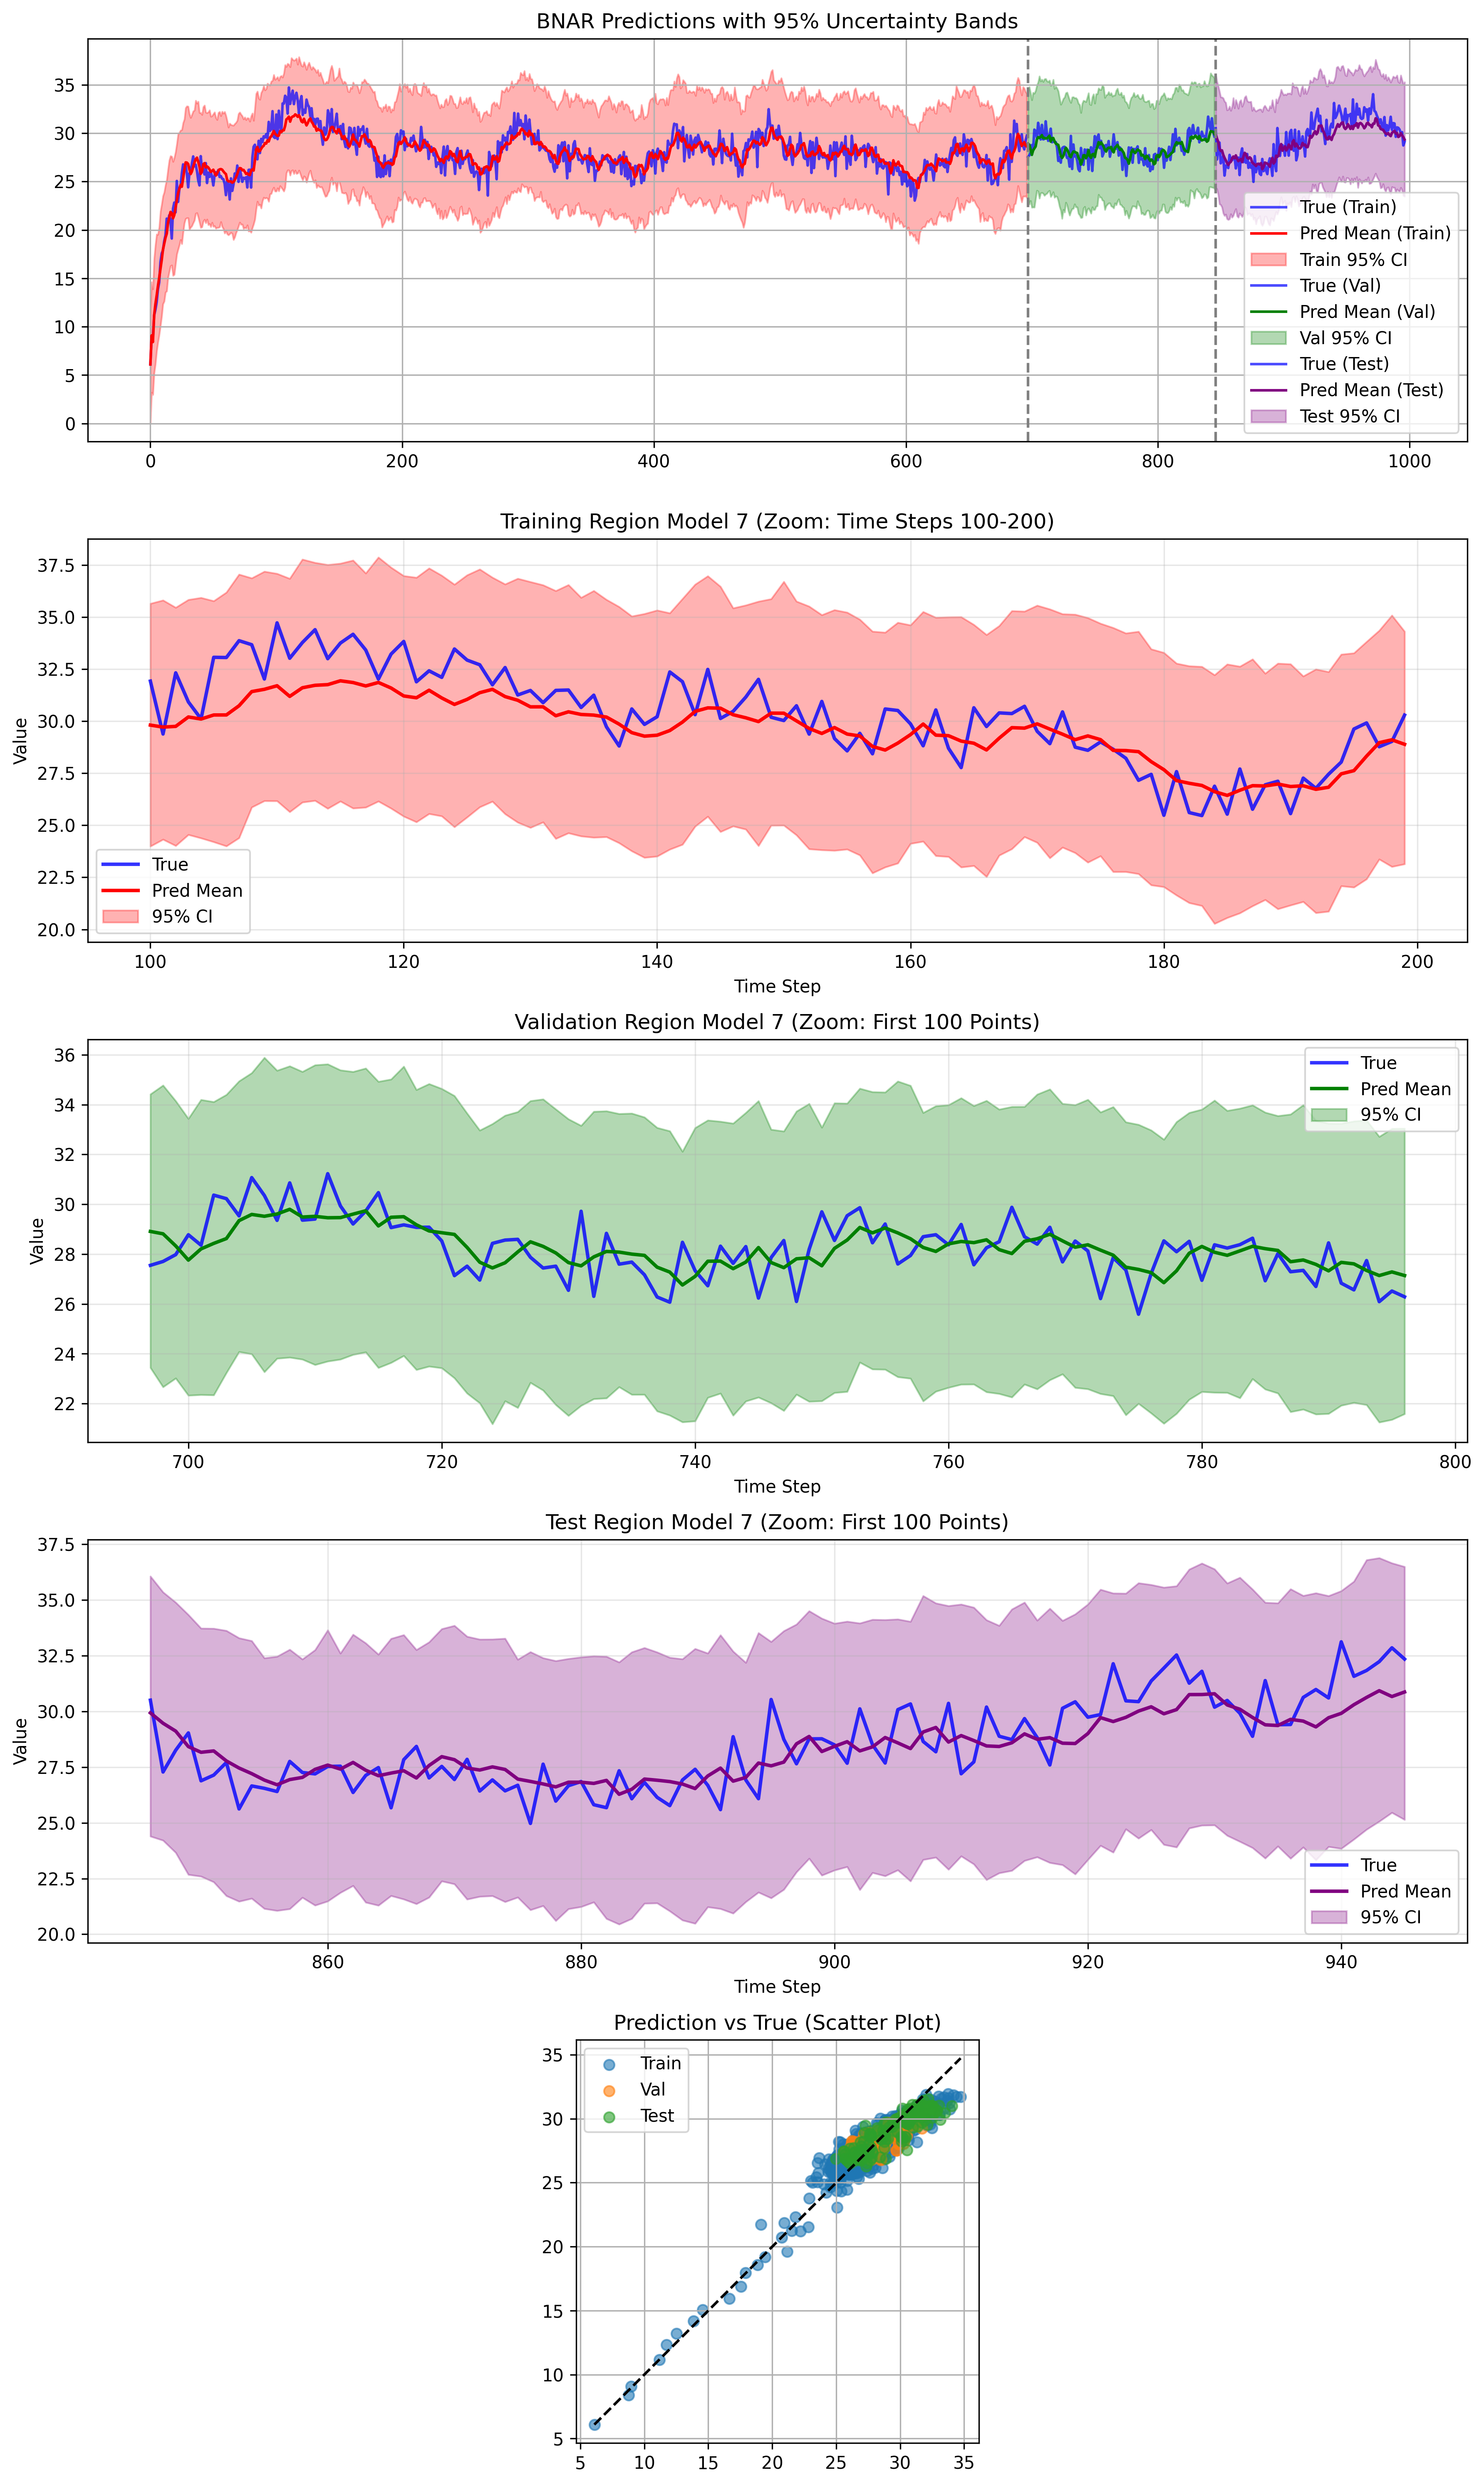

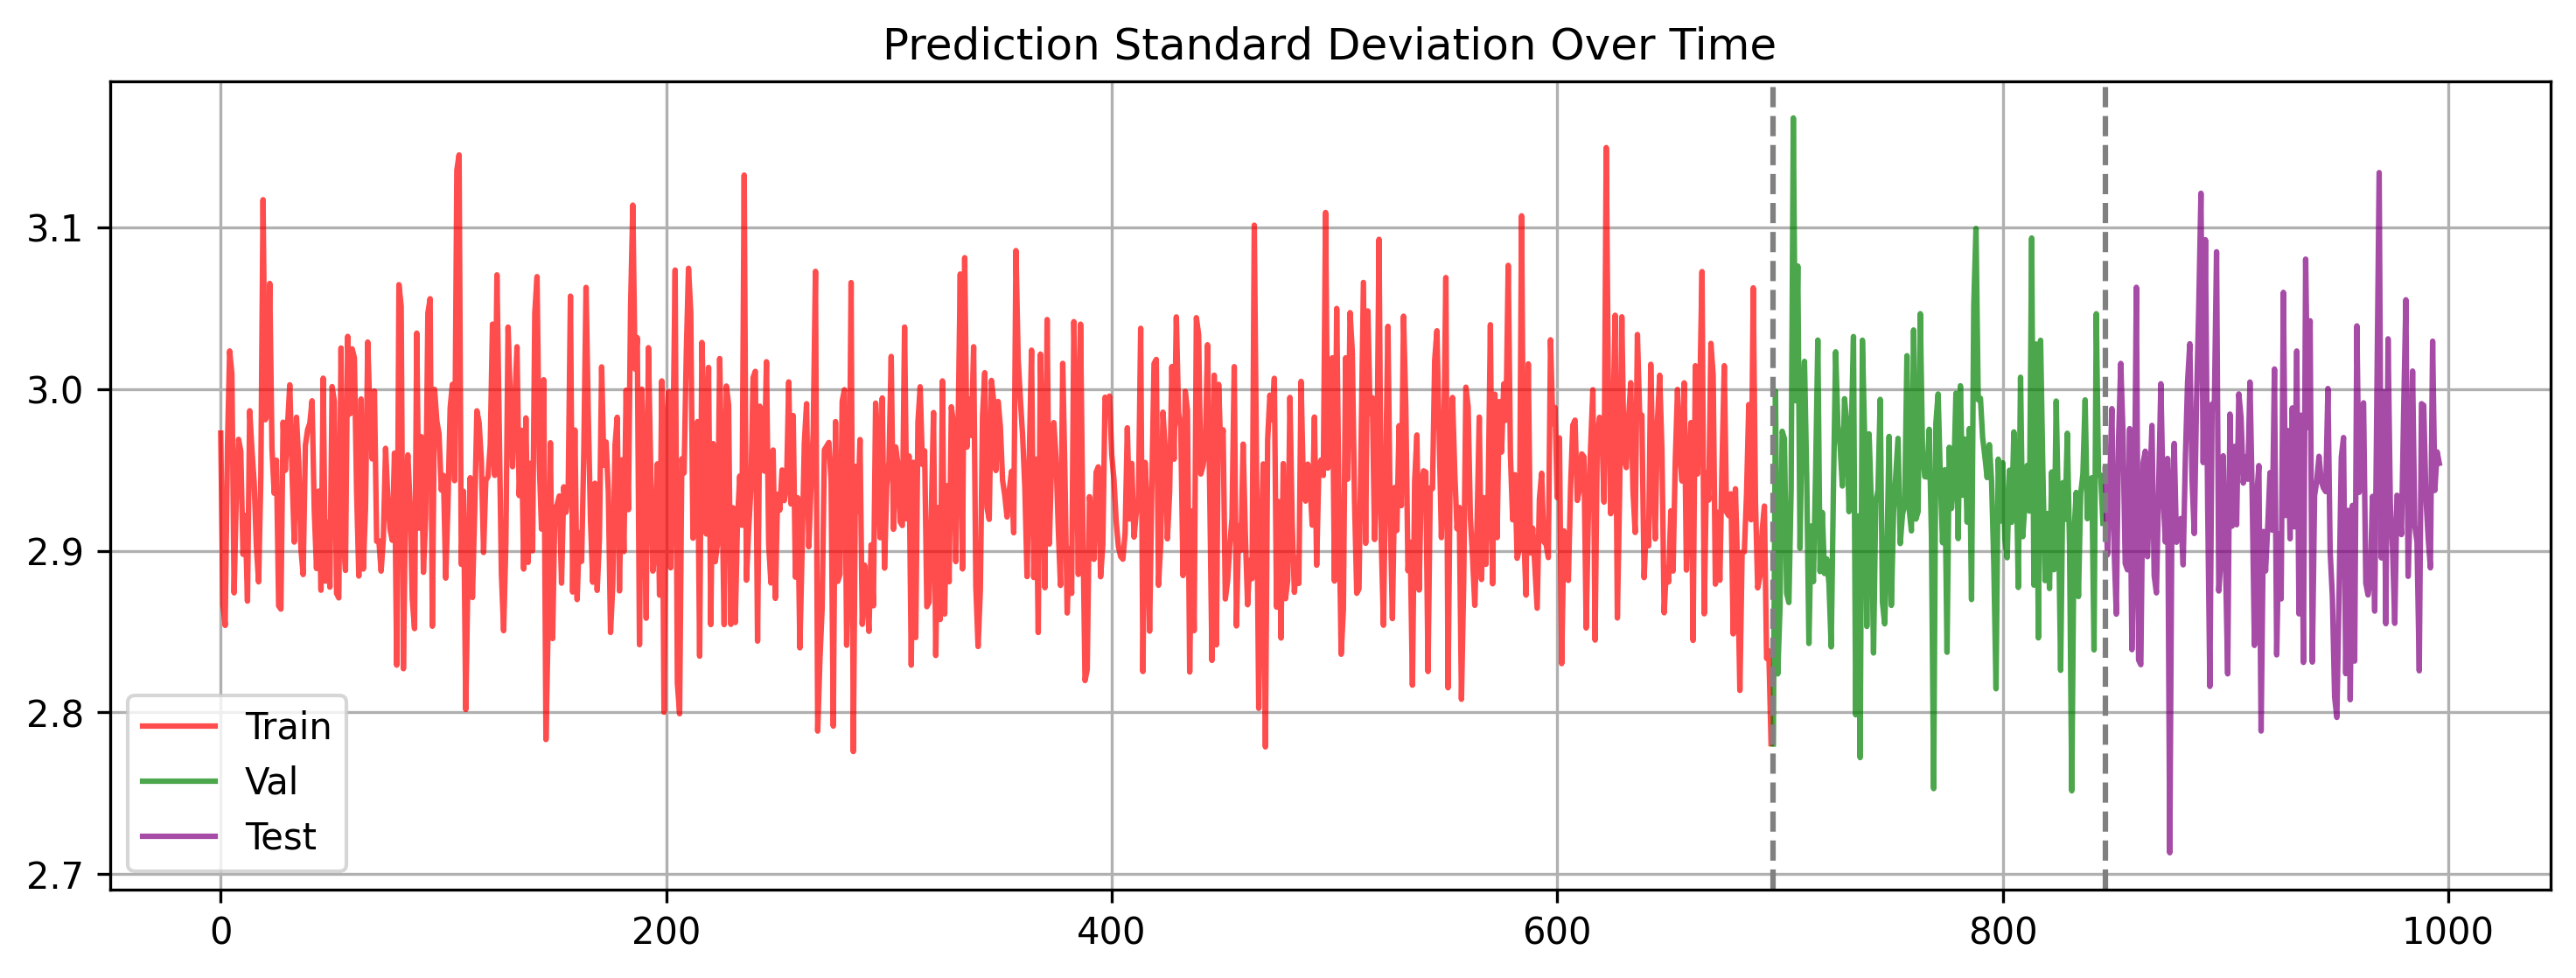

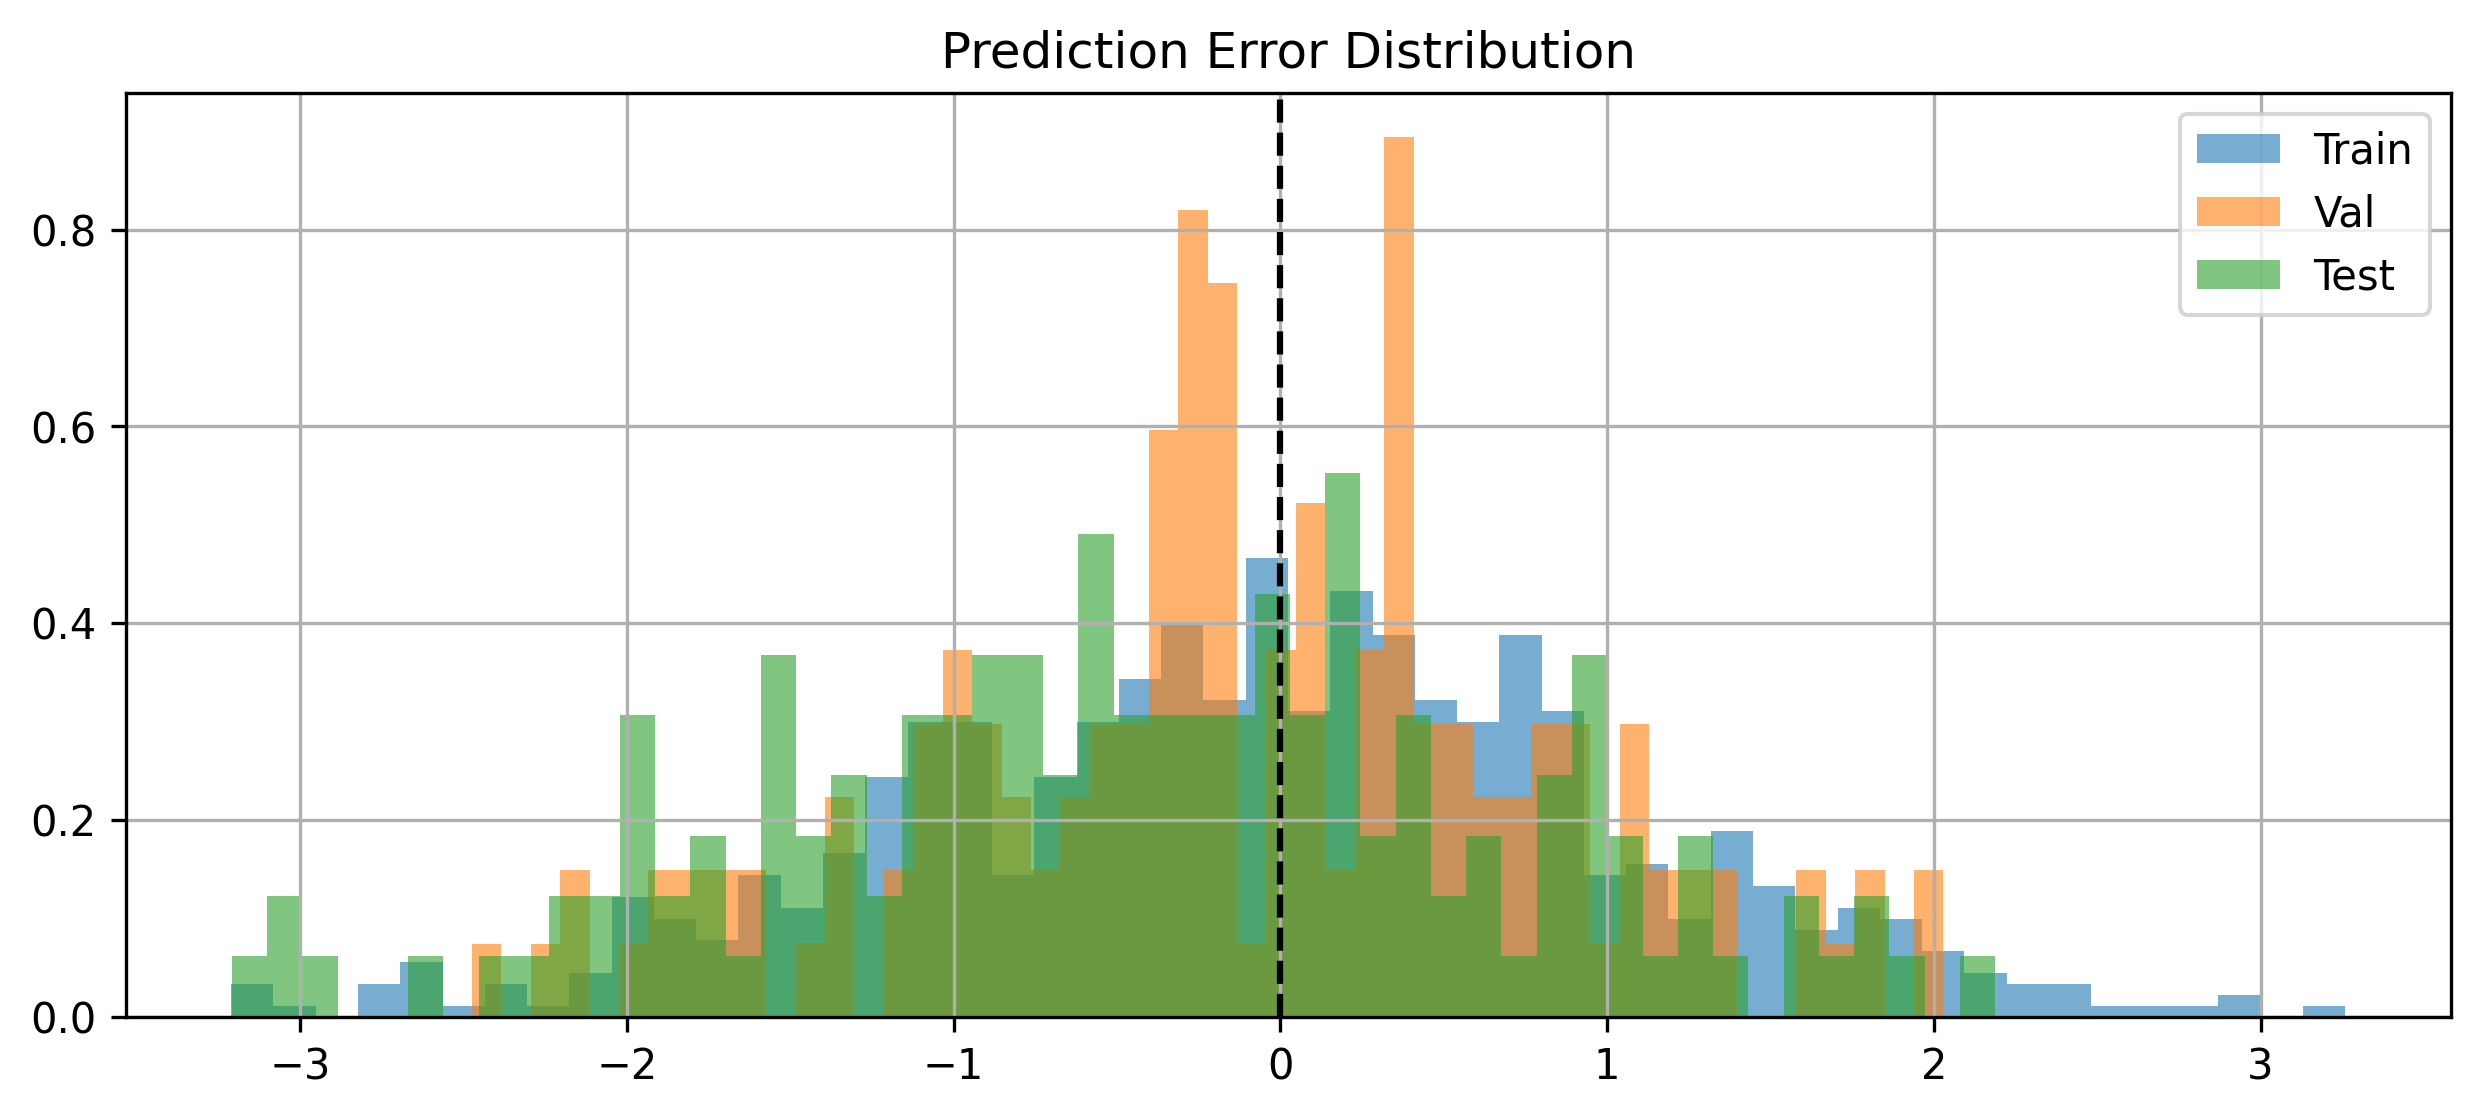


Coverage Probability (95% CI):
Train: 1.000
Val:   1.000
Test:  1.000

RMSE:
Train: 1.0842
Val:   0.9368
Test:  1.1926


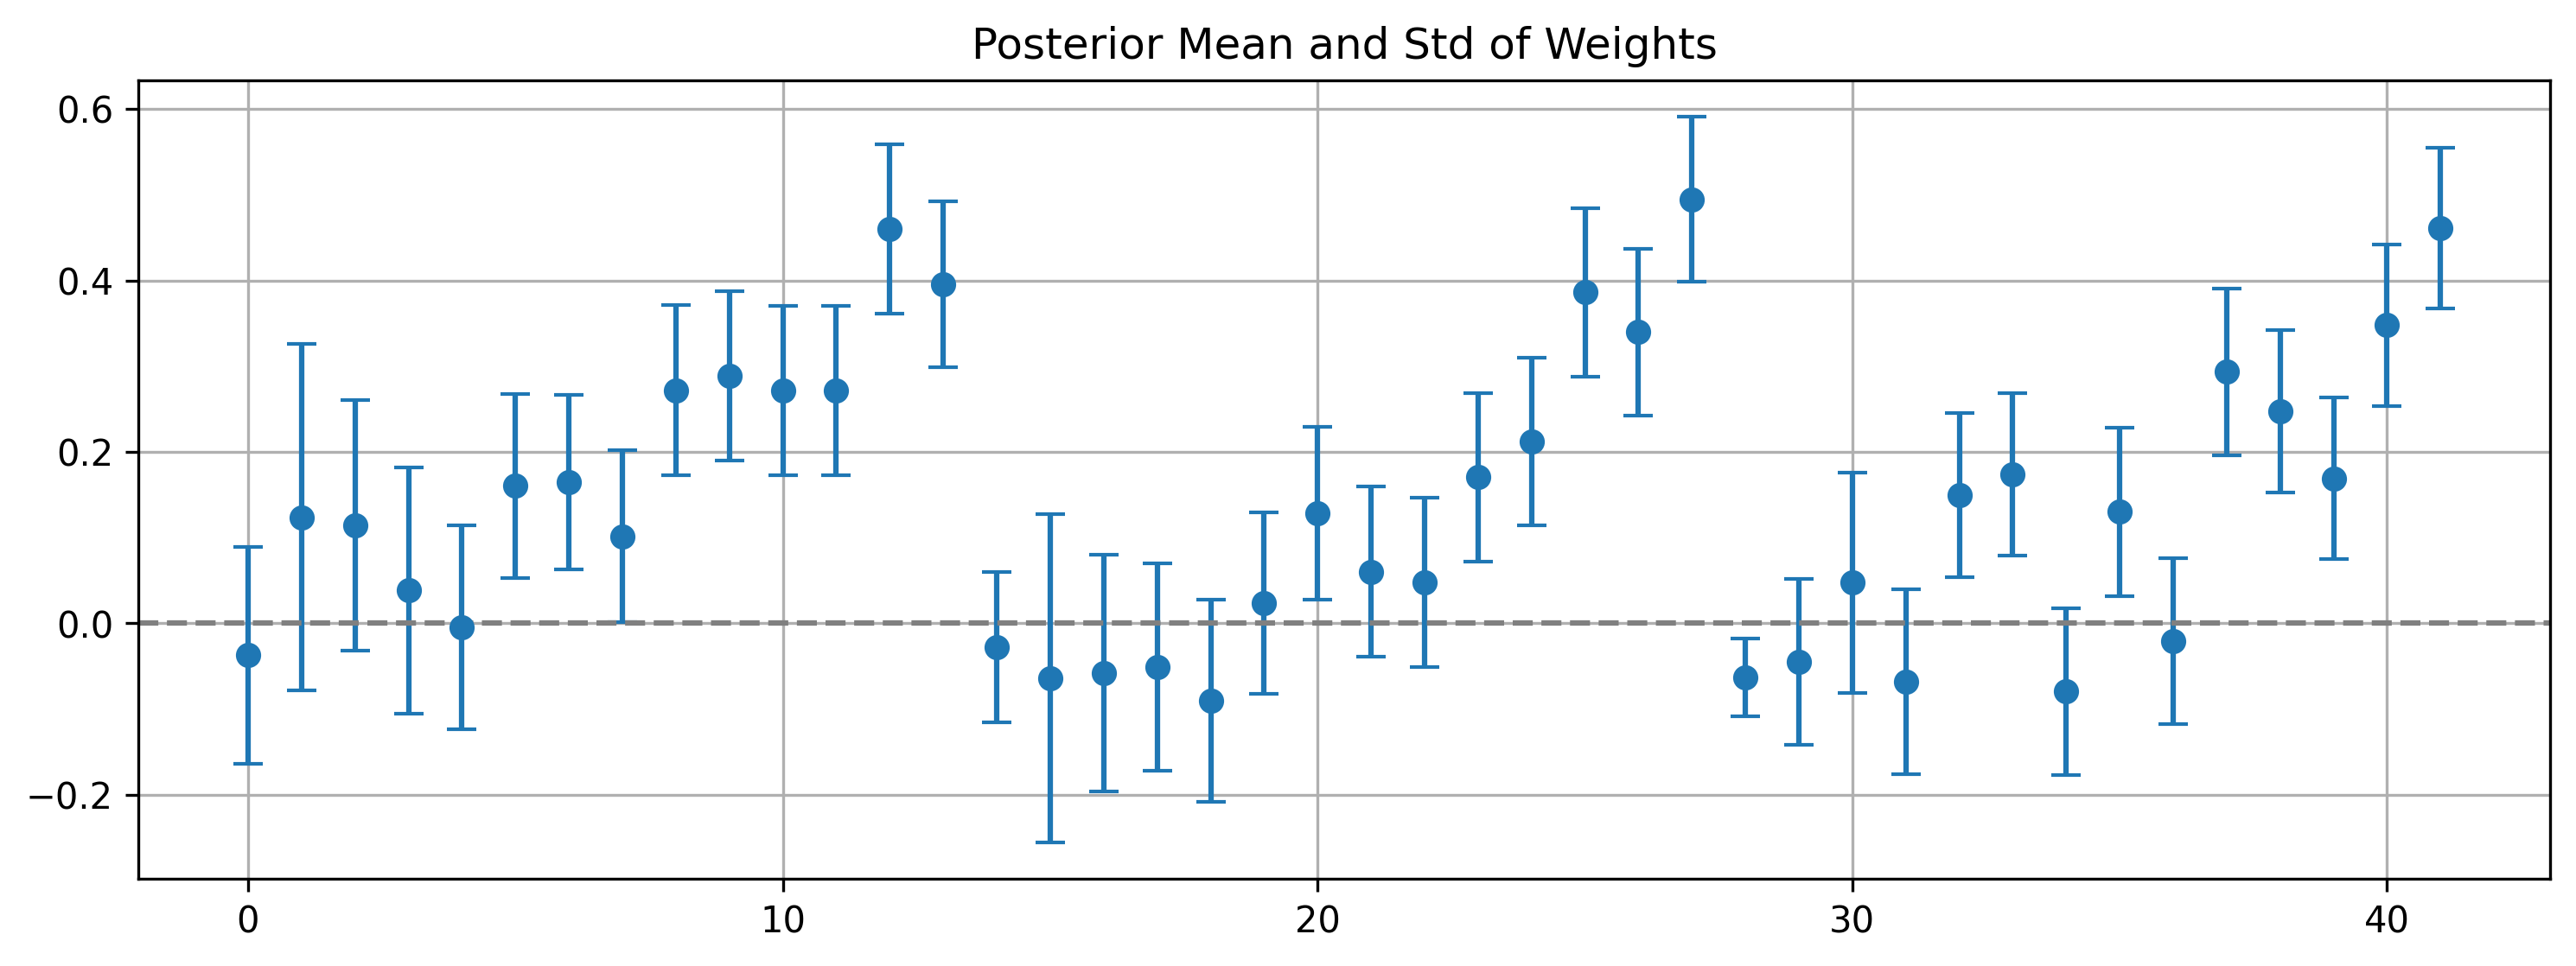

In [ ]:
# ------------------------------------------------------------
# 1. Monte-Carlo Prediction with Uncertainty + Inverse Scaling
# ------------------------------------------------------------
def predict_with_uncertainty(model, X, n_samples=1000, scale_factor=1.0):
    """
    Generate predictive samples & compute mean, std, CI.
    Automatically inverts scaling using scale_factor.
    """
    model.eval()
    with torch.no_grad():
        samples = []
        for _ in range(n_samples):
            yhat, sigma_eps, _ = model.forward(X, sample=True, kl_weight=0.0)
            noisy = yhat + torch.randn_like(yhat) * sigma_eps
            samples.append(noisy.cpu().numpy())

        # shape: (N, samples)
        samples = np.array(samples).squeeze(-1).T

        # inverse scaling
        samples = samples * scale_factor

        # predictive stats
        pred_mean  = np.mean(samples, axis=1)
        pred_std   = np.std(samples, axis=1)
        pred_lower = np.percentile(samples, 2.5, axis=1)
        pred_upper = np.percentile(samples, 97.5, axis=1)

        return pred_mean, pred_std, pred_lower, pred_upper, samples

##############################################################
d = int(hard_best_model["d"])
degree = int(hard_best_model["degree"])
# -------------------------
# Build lagged design
# -------------------------
X_lag, y = build_lag_matrix(x_scaled, d)

X_basis = build_bernstein_full_basis(X_lag, degree=degree)

N = len(y)
n_train = int(0.7 * N)
n_val   = int(0.15 * N)

idx_tr = slice(0, n_train)
idx_va = slice(n_train, n_train + n_val)
idx_te = slice(n_train + n_val, N)

Xtr, ytr = X_basis[idx_tr], y[idx_tr]
Xva, yva = X_basis[idx_va], y[idx_va]
Xte, yte = X_basis[idx_te], y[idx_te]

Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=device)
ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).unsqueeze(1)
Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
yva_t = torch.tensor(yva, dtype=torch.float32, device=device).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32, device=device)
yte_t = torch.tensor(yte, dtype=torch.float32, device=device).unsqueeze(1)

# ------------------------------------------------------------
# Build models and Train for Train/Val/Test
# ------------------------------------------------------------
model = BNAR_FullCov(
    d=Xtr.shape[1],
    activation='tanh',
    prior_std=1.0,
    sigma_floor=1e-6
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("\nTraining final model...")

for epoch in range(3000):
    model.train()
    optimizer.zero_grad()

    nelbo, _ = model.negative_elbo(Xtr_t, ytr_t, kl_weight=0.1)
    nelbo.backward()
    optimizer.step()

    if epoch % 500 == 0:
        model.eval()
        with torch.no_grad():
            yhat_va, _, _ = model.forward(Xva_t, sample=False)
            rmse_va = torch.sqrt(torch.mean((yva_t - yhat_va)**2))
        print(f"Epoch {epoch:4d} | NELBO={nelbo.item():.3f} | Val RMSE={rmse_va.item():.4f}")

# ------------------------------------------------------------
# 2. Generate Predictions for Train/Val/Test
# ------------------------------------------------------------
print("Generating MC predictions...")

ytr_pred_mean, ytr_pred_std, ytr_pred_lower, ytr_pred_upper, tr_samples = \
    predict_with_uncertainty(model, Xtr_t, n_samples=1000, scale_factor=c)

yva_pred_mean, yva_pred_std, yva_pred_lower, yva_pred_upper, va_samples = \
    predict_with_uncertainty(model, Xva_t, n_samples=1000, scale_factor=c)

yte_pred_mean, yte_pred_std, yte_pred_lower, yte_pred_upper, te_samples = \
    predict_with_uncertainty(model, Xte_t, n_samples=1000, scale_factor=c)


# ------------------------------------------------------------
# 3. Inverse-Scaled True Values
# ------------------------------------------------------------
ytr_true = ytr_t.cpu().numpy().flatten() * c
yva_true = yva_t.cpu().numpy().flatten() * c
yte_true = yte_t.cpu().numpy().flatten() * c


# ------------------------------------------------------------
# 4. Time Indices
# ------------------------------------------------------------
time_tr = np.arange(len(ytr_true))
time_va = np.arange(len(ytr_true), len(ytr_true) + len(yva_true))
time_te = np.arange(len(ytr_true) + len(yva_true),
                    len(ytr_true) + len(yva_true) + len(yte_true))


# ============================================================
#                   FULL VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(12, 20))

# ---------------------------
# Plot 1 — Full Series
# ---------------------------
ax1 = plt.subplot(5,1,1)

# Train
ax1.plot(time_tr, ytr_true, 'b-', label='True (Train)', alpha=0.7)
ax1.plot(time_tr, ytr_pred_mean, 'r-', label='Pred Mean (Train)')
ax1.fill_between(time_tr, ytr_pred_lower, ytr_pred_upper,
                 color='red', alpha=0.3, label='Train 95% CI')

# Val
ax1.plot(time_va, yva_true, 'b-', alpha=0.7, label='True (Val)')
ax1.plot(time_va, yva_pred_mean, 'g-', label='Pred Mean (Val)')
ax1.fill_between(time_va, yva_pred_lower, yva_pred_upper,
                 color='green', alpha=0.3, label='Val 95% CI')

# Test
ax1.plot(time_te, yte_true, 'b-', alpha=0.7, label='True (Test)')
ax1.plot(time_te, yte_pred_mean, 'purple', label='Pred Mean (Test)')
ax1.fill_between(time_te, yte_pred_lower, yte_pred_upper,
                 color='purple', alpha=0.3, label='Test 95% CI')

ax1.axvline(len(ytr_true), color='gray', linestyle='--')
ax1.axvline(len(ytr_true) + len(yva_true), color='gray', linestyle='--')

ax1.set_title("BNAR Predictions with 95% Uncertainty Bands")
ax1.legend()
ax1.grid(True)


# Plot 2: Training region zoom
ax2 = plt.subplot(5, 1, 2)
ax2.plot(time_tr[100:200], ytr_true[100:200], 'b-', alpha=0.8, label='True', linewidth=2)
ax2.plot(time_tr[100:200], ytr_pred_mean[100:200], 'r-', label='Pred Mean', linewidth=2)
ax2.fill_between(time_tr[100:200], ytr_pred_lower[100:200], ytr_pred_upper[100:200],
                      alpha=0.3, color='red', label='95% CI')
ax2.set_title(f'Training Region Model {id} (Zoom: Time Steps 100-200)')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Validation region zoom
ax3 = plt.subplot(5, 1, 3)
ax3.plot(time_va[:100], yva_true[:100], 'b-', alpha=0.8, label='True', linewidth=2)
ax3.plot(time_va[:100], yva_pred_mean[:100], 'g-', label='Pred Mean', linewidth=2)
ax3.fill_between(time_va[:100], yva_pred_lower[:100], yva_pred_upper[:100],
                      alpha=0.3, color='green', label='95% CI')
ax3.set_title(f'Validation Region Model {id} (Zoom: First 100 Points)')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Value')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Test region zoom
ax4 = plt.subplot(5, 1, 4)
ax4.plot(time_te[:100], yte_true[:100], 'b-', alpha=0.8, label='True', linewidth=2)
ax4.plot(time_te[:100], yte_pred_mean[:100], 'purple', label='Pred Mean', linewidth=2)
ax4.fill_between(time_te[:100], yte_pred_lower[:100], yte_pred_upper[:100],
                      alpha=0.3, color='purple', label='95% CI')
ax4.set_title(f'Test Region Model {id} (Zoom: First 100 Points)')
ax4.set_xlabel('Time Step')
ax4.set_ylabel('Value')
ax4.legend()
ax4.grid(True, alpha=0.3)




# ---------------------------
# Plot 5 — Scatter (True vs Pred)
# ---------------------------
ax5 = plt.subplot(5,1,5)

ax5.scatter(ytr_true, ytr_pred_mean, alpha=0.6, label='Train')
ax5.scatter(yva_true, yva_pred_mean, alpha=0.6, label='Val')
ax5.scatter(yte_true, yte_pred_mean, alpha=0.6, label='Test')

mn = min(ytr_true.min(), ytr_pred_mean.min())
mx = max(ytr_true.max(), ytr_pred_mean.max())
ax5.plot([mn, mx], [mn, mx], 'k--')

ax5.set_title("Prediction vs True (Scatter Plot)")
ax5.set_aspect("equal")
ax5.grid(True)
ax5.legend()

plt.tight_layout()
plt.show()


# ============================================================
#                   UNCERTAINTY + ERRORS
# ============================================================

# ---------------------------
# 6 — Uncertainty Over Time
# ---------------------------
plt.figure(figsize=(12,4))
plt.plot(time_tr, ytr_pred_std, 'r-', alpha=0.7, label='Train')
plt.plot(time_va, yva_pred_std, 'g-', alpha=0.7, label='Val')
plt.plot(time_te, yte_pred_std, 'purple', alpha=0.7, label='Test')
plt.axvline(len(ytr_true), color='gray', linestyle='--')
plt.axvline(len(ytr_true)+len(yva_true), color='gray', linestyle='--')
plt.title("Prediction Standard Deviation Over Time")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------
# 7 — Error Histogram
# ---------------------------
plt.figure(figsize=(10,4))

err_tr = ytr_pred_mean - ytr_true
err_va = yva_pred_mean - yva_true
err_te = yte_pred_mean - yte_true

plt.hist(err_tr, bins=50, density=True, alpha=0.6, label='Train')
plt.hist(err_va, bins=50, density=True, alpha=0.6, label='Val')
plt.hist(err_te, bins=50, density=True, alpha=0.6, label='Test')
plt.axvline(0, color='k', linestyle='--')
plt.title("Prediction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------
# 8 — Coverage Probability (95%)
# ---------------------------
coverage_tr = np.mean((ytr_true >= ytr_pred_lower) & (ytr_true <= ytr_pred_upper))
coverage_va = np.mean((yva_true >= yva_pred_lower) & (yva_true <= yva_pred_upper))
coverage_te = np.mean((yte_true >= yte_pred_lower) & (yte_true <= yte_pred_upper))

print("\nCoverage Probability (95% CI):")
print(f"Train: {coverage_tr:.3f}")
print(f"Val:   {coverage_va:.3f}")
print(f"Test:  {coverage_te:.3f}")


# ---------------------------
# 9 — RMSE
# ---------------------------
rmse_tr = np.sqrt(np.mean(err_tr**2))
rmse_va = np.sqrt(np.mean(err_va**2))
rmse_te = np.sqrt(np.mean(err_te**2))

print("\nRMSE:")
print(f"Train: {rmse_tr:.4f}")
print(f"Val:   {rmse_va:.4f}")
print(f"Test:  {rmse_te:.4f}")


# ---------------------------
# 10 — Posterior Weights Mean and Std
# ---------------------------
weights = model.m_w.detach().cpu().numpy()
stds = torch.exp(model.log_diag_Lq).detach().cpu().numpy()

plt.figure(figsize=(12,4))
plt.errorbar(np.arange(len(weights)), weights, yerr=stds,
             fmt='o', capsize=4)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Posterior Mean and Std of Weights")
plt.grid(True)
plt.show()

# Normlity Test for residuals


Train Residual Normality Tests
---------------------------------------------
Shapiro-Wilk:  stat=0.9980, p=0.5982
Jarque-Bera:   stat=0.5838, p=0.7469

Validation Residual Normality Tests
---------------------------------------------
Shapiro-Wilk:  stat=0.9907, p=0.4369
Jarque-Bera:   stat=0.8025, p=0.6695

Test Residual Normality Tests
---------------------------------------------
Shapiro-Wilk:  stat=0.9938, p=0.7701
Jarque-Bera:   stat=0.9047, p=0.6361


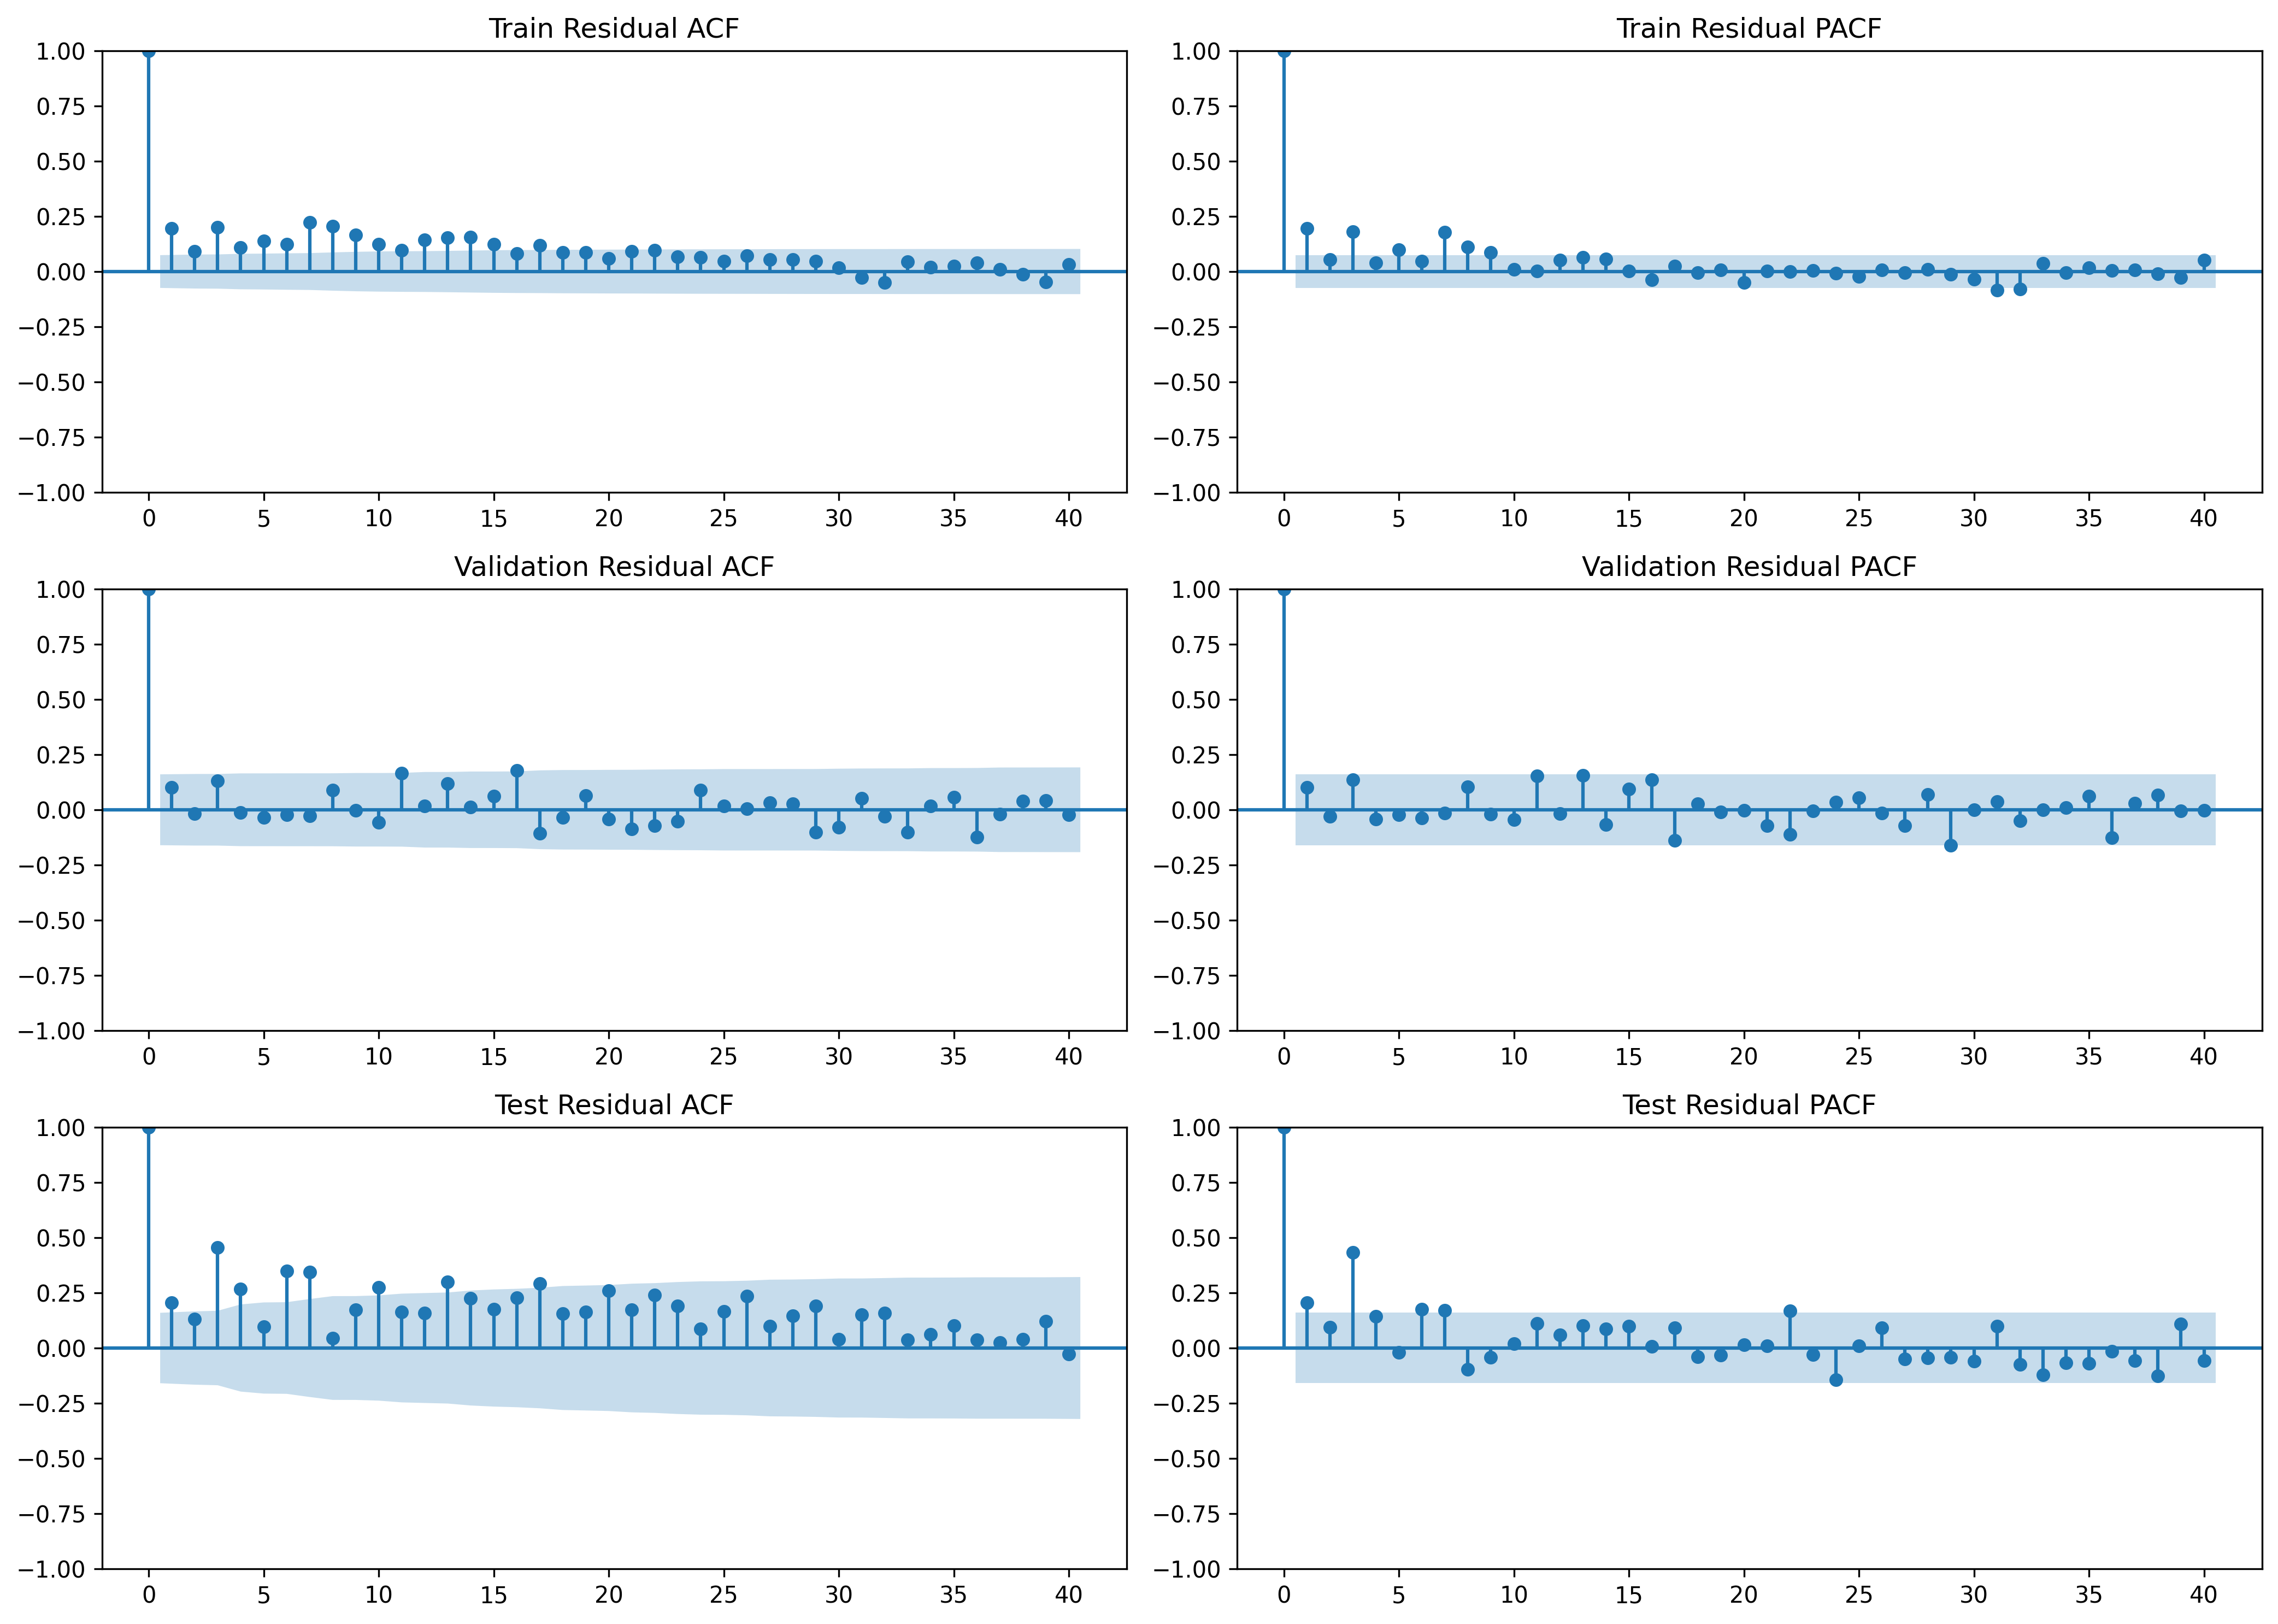


Train Ljung-Box Test (lag=20)
---------------------------------------------
LB statistic = 282.2352
p-value      = 3.375e-48

Validation Ljung-Box Test (lag=20)
---------------------------------------------
LB statistic = 22.3378
p-value      = 0.3225

Test Ljung-Box Test (lag=20)
---------------------------------------------
LB statistic = 191.2552
p-value      = 5.989e-30


In [ ]:
# ============================================================
#            RESIDUAL DIAGNOSTICS FOR BNAR
# ============================================================

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ------------------------------------------------------------
# 1. Compute residuals
# ------------------------------------------------------------
res_tr = ytr_true - ytr_pred_mean
res_va = yva_true - yva_pred_mean
res_te = yte_true - yte_pred_mean

# ------------------------------------------------------------
# 2. Normality tests (Shapiro + Jarque-Bera)
# ------------------------------------------------------------
def normality_tests(residuals, name=""):
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    jb_stat, jb_p = stats.jarque_bera(residuals)

    print(f"\n{name} Residual Normality Tests")
    print("-" * 45)
    print(f"Shapiro-Wilk:  stat={shapiro_stat:.4f}, p={shapiro_p:.4g}")
    print(f"Jarque-Bera:   stat={jb_stat:.4f}, p={jb_p:.4g}")

normality_tests(res_tr, "Train")
normality_tests(res_va, "Validation")
normality_tests(res_te, "Test")


# ------------------------------------------------------------
# 3. Residual ACF / PACF plots
# ------------------------------------------------------------
max_lag = 40

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

plot_acf(res_tr, lags=max_lag, ax=axes[0,0])
plot_pacf(res_tr, lags=max_lag, ax=axes[0,1], method="ywm")
axes[0,0].set_title("Train Residual ACF")
axes[0,1].set_title("Train Residual PACF")

plot_acf(res_va, lags=max_lag, ax=axes[1,0])
plot_pacf(res_va, lags=max_lag, ax=axes[1,1], method="ywm")
axes[1,0].set_title("Validation Residual ACF")
axes[1,1].set_title("Validation Residual PACF")

plot_acf(res_te, lags=max_lag, ax=axes[2,0])
plot_pacf(res_te, lags=max_lag, ax=axes[2,1], method="ywm")
axes[2,0].set_title("Test Residual ACF")
axes[2,1].set_title("Test Residual PACF")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Ljung-Box test (whiteness test)
# ------------------------------------------------------------
def ljung_box_test(residuals, name="", lags=20):
    lb = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    stat = lb["lb_stat"].values[0]
    pval = lb["lb_pvalue"].values[0]

    print(f"\n{name} Ljung-Box Test (lag={lags})")
    print("-" * 45)
    print(f"LB statistic = {stat:.4f}")
    print(f"p-value      = {pval:.4g}")

ljung_box_test(res_tr, "Train")
ljung_box_test(res_va, "Validation")
ljung_box_test(res_te, "Test")

# Residual Test on standardized residuals


Train STANDARDIZED Residual Normality Tests
-------------------------------------------------------
Shapiro-Wilk:  stat=0.9980, p=0.6126
Jarque-Bera:   stat=0.4364, p=0.804

Validation STANDARDIZED Residual Normality Tests
-------------------------------------------------------
Shapiro-Wilk:  stat=0.9900, p=0.3689
Jarque-Bera:   stat=0.8192, p=0.6639

Test STANDARDIZED Residual Normality Tests
-------------------------------------------------------
Shapiro-Wilk:  stat=0.9945, p=0.8375
Jarque-Bera:   stat=0.9527, p=0.621


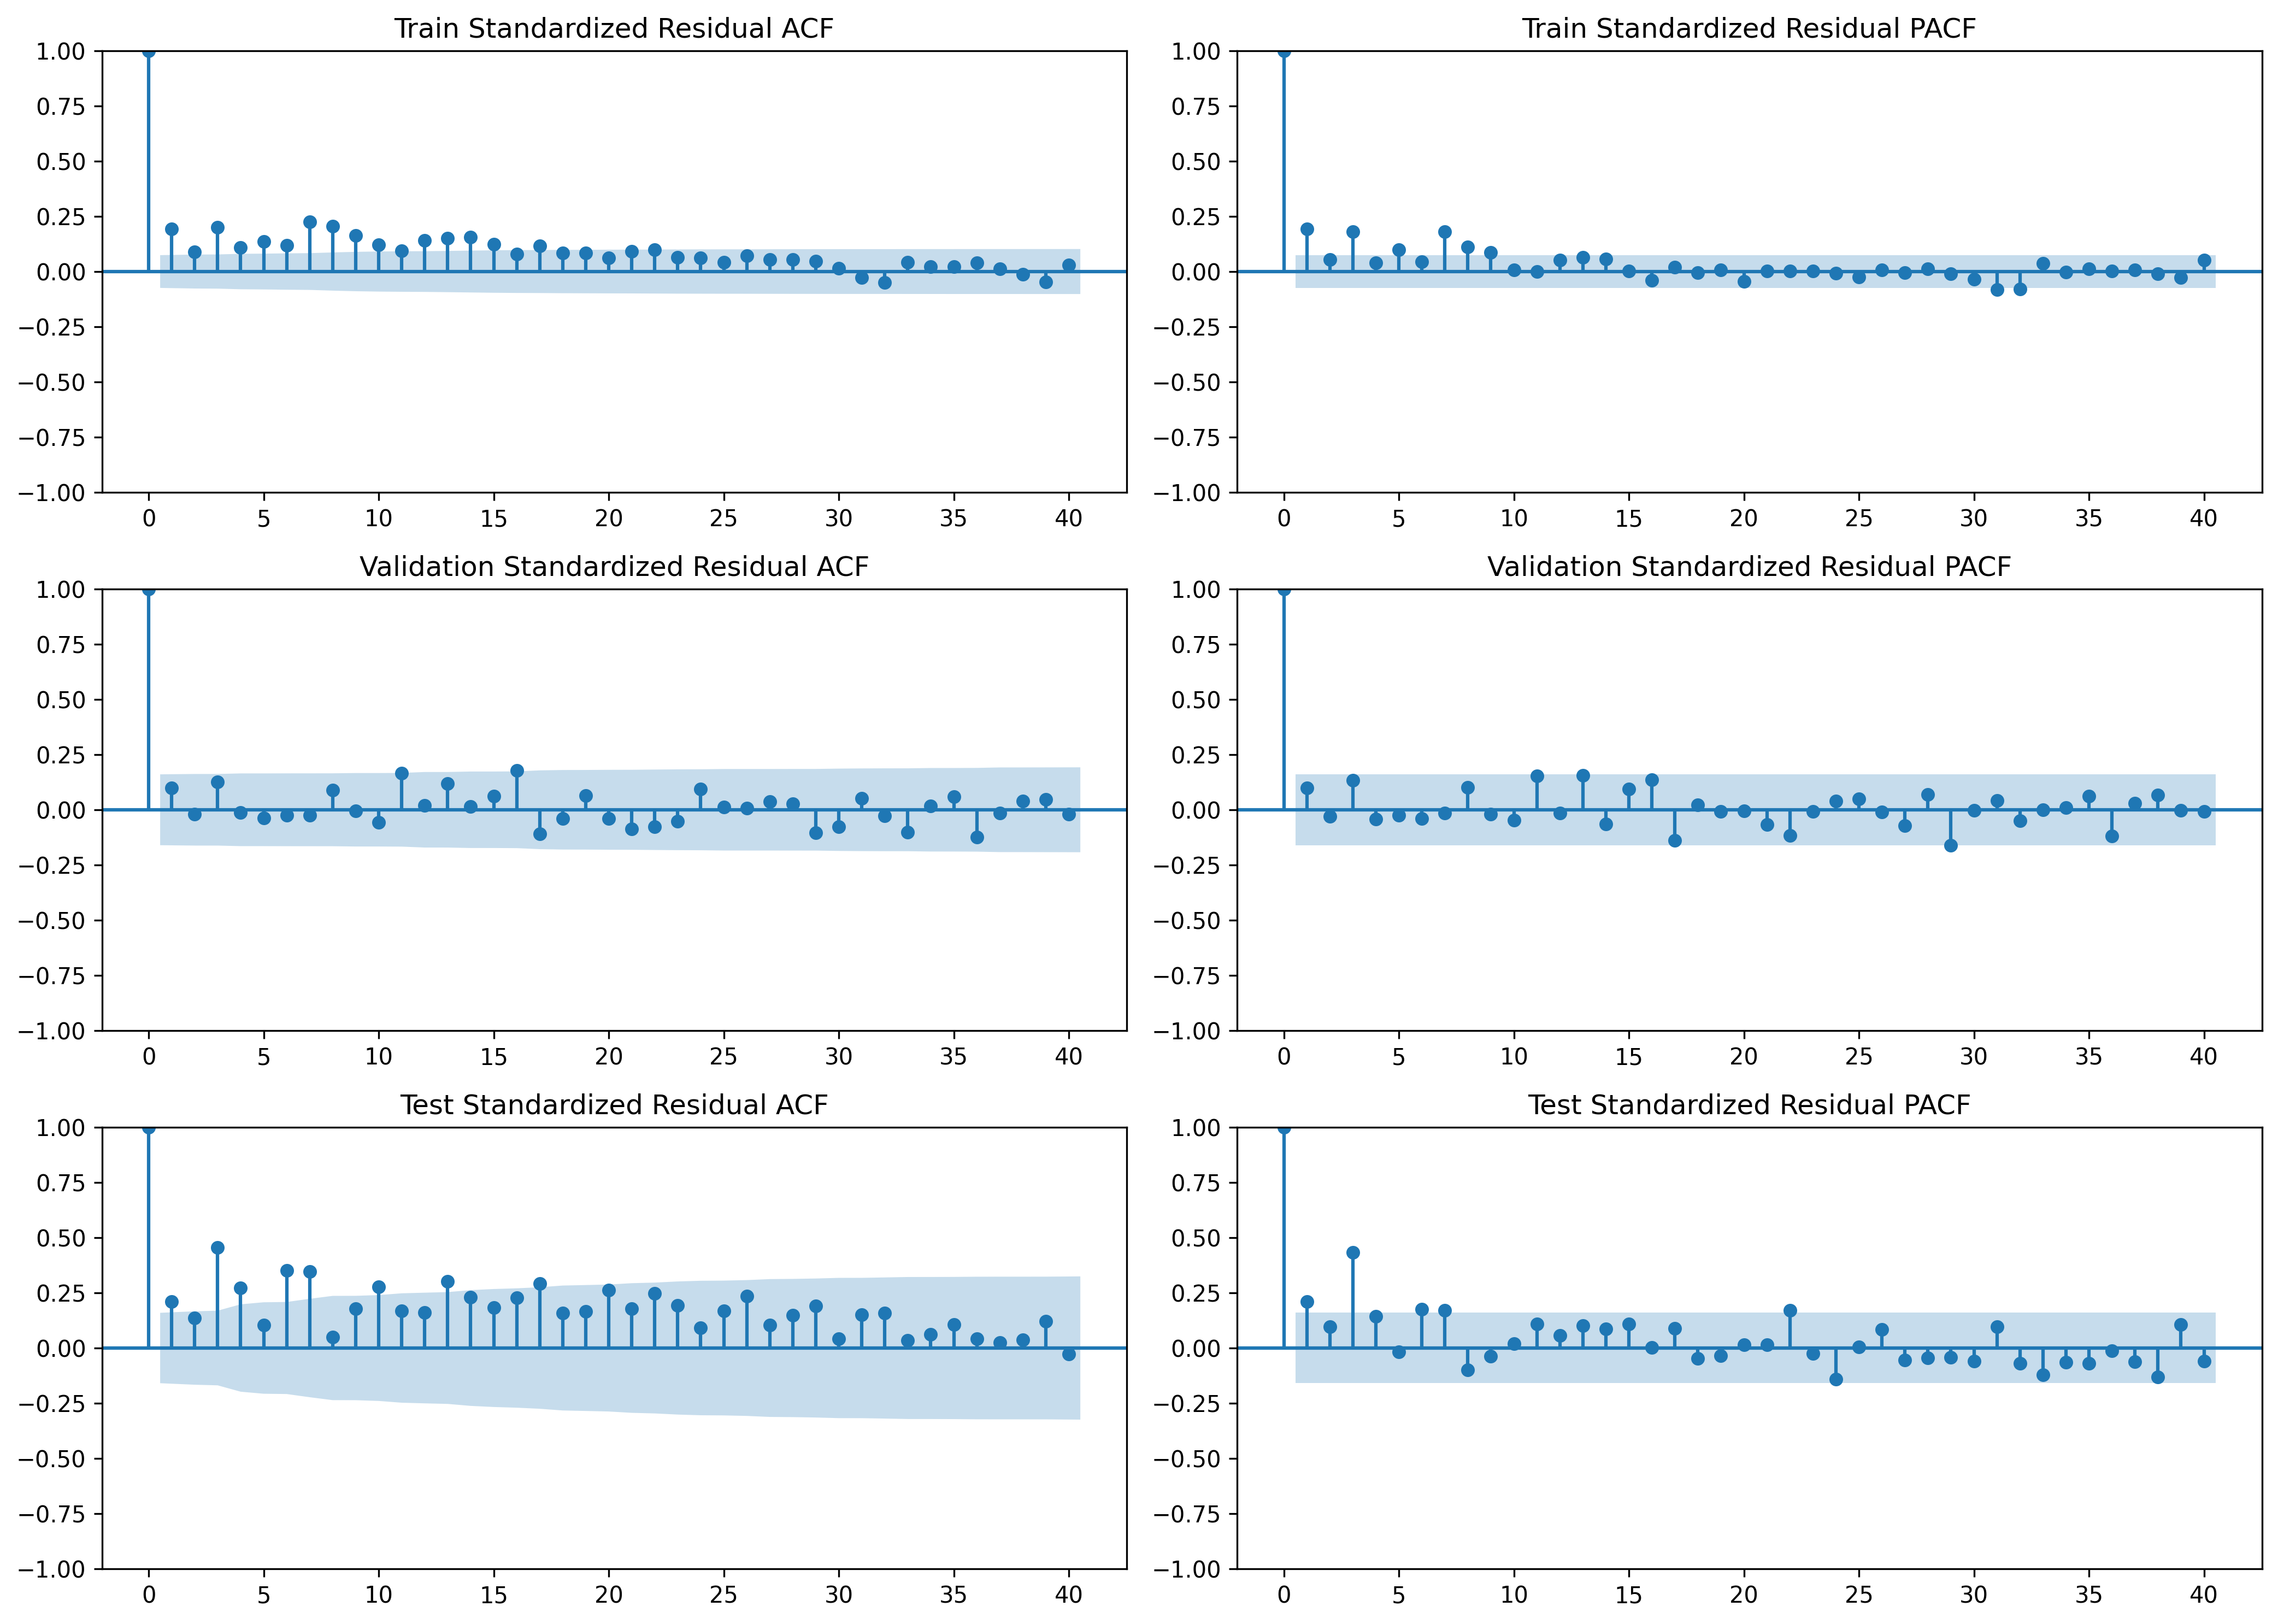


Train Ljung–Box Test on STANDARDIZED Residuals (lag=20)
-----------------------------------------------------------------
LB statistic = 277.7804
p-value      = 2.716e-47

Validation Ljung–Box Test on STANDARDIZED Residuals (lag=20)
-----------------------------------------------------------------
LB statistic = 22.4518
p-value      = 0.3165

Test Ljung–Box Test on STANDARDIZED Residuals (lag=20)
-----------------------------------------------------------------
LB statistic = 195.4350
p-value      = 8.98e-31


In [ ]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# 1. Compute standardized residuals
# ------------------------------------------------------------
# Avoid division by zero
eps = 1e-8

std_res_tr = (ytr_true - ytr_pred_mean) / (ytr_pred_std + eps)
std_res_va = (yva_true - yva_pred_mean) / (yva_pred_std + eps)
std_res_te = (yte_true - yte_pred_mean) / (yte_pred_std + eps)


# ------------------------------------------------------------
# 2. Normality tests on standardized residuals
# ------------------------------------------------------------
def standardized_normality_tests(residuals, name=""):
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    jb_stat, jb_p = stats.jarque_bera(residuals)

    print(f"\n{name} STANDARDIZED Residual Normality Tests")
    print("-" * 55)
    print(f"Shapiro-Wilk:  stat={shapiro_stat:.4f}, p={shapiro_p:.4g}")
    print(f"Jarque-Bera:   stat={jb_stat:.4f}, p={jb_p:.4g}")

standardized_normality_tests(std_res_tr, "Train")
standardized_normality_tests(std_res_va, "Validation")
standardized_normality_tests(std_res_te, "Test")


# ------------------------------------------------------------
# 3. ACF / PACF of standardized residuals
# ------------------------------------------------------------
max_lag = 40

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

plot_acf(std_res_tr, lags=max_lag, ax=axes[0,0])
plot_pacf(std_res_tr, lags=max_lag, ax=axes[0,1], method="ywm")
axes[0,0].set_title("Train Standardized Residual ACF")
axes[0,1].set_title("Train Standardized Residual PACF")

plot_acf(std_res_va, lags=max_lag, ax=axes[1,0])
plot_pacf(std_res_va, lags=max_lag, ax=axes[1,1], method="ywm")
axes[1,0].set_title("Validation Standardized Residual ACF")
axes[1,1].set_title("Validation Standardized Residual PACF")

plot_acf(std_res_te, lags=max_lag, ax=axes[2,0])
plot_pacf(std_res_te, lags=max_lag, ax=axes[2,1], method="ywm")
axes[2,0].set_title("Test Standardized Residual ACF")
axes[2,1].set_title("Test Standardized Residual PACF")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Ljung–Box test on standardized residuals
# ------------------------------------------------------------
def ljung_box_standardized(residuals, name="", lags=20):
    lb = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    stat = lb["lb_stat"].values[0]
    pval = lb["lb_pvalue"].values[0]

    print(f"\n{name} Ljung–Box Test on STANDARDIZED Residuals (lag={lags})")
    print("-" * 65)
    print(f"LB statistic = {stat:.4f}")
    print(f"p-value      = {pval:.4g}")

ljung_box_standardized(std_res_tr, "Train")
ljung_box_standardized(std_res_va, "Validation")
ljung_box_standardized(std_res_te, "Test")
